# BasicTask6
EnKFを実装し、KFと比較する。Whitaker and Hamill (2002)によるSerial EnSRF, Bishop et al. (2001)によるETKF、Hunt et al. (2007)によるLETKF、PO法などの解法がある。2つ以上実装すること。

## Lorenz96モデルの実装

In [3]:
# 各種メソッドの定義
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Lorenz96モデルの定義
def L96(x, F):
    """
    x: shape (N,) または (N, M)
    F: スカラーまたは shape (N, 1/ M とブロードキャスト可能)
    """
    x = np.asarray(x)
    roll_p1 = np.roll(x, -1, axis=0)
    roll_m1 = np.roll(x, 1, axis=0)
    roll_m2 = np.roll(x, 2, axis=0)
    return (roll_p1 - roll_m2) * roll_m1 - x + F
## オイラー法の実装
def euler_step(x, F, dt):
    """
    オイラー法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    dxdt = L96(x, F)
    return x + dxdt * dt
## 4次のルンゲクッタ法の実装
def rk4_step(x, F, dt):
    """
    4次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F) * dt
    k2 = L96(x + 0.5 * k1, F) * dt
    k3 = L96(x + 0.5 * k2, F) * dt
    k4 = L96(x + k3, F) * dt
    return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6

## 2次のルンゲクッタ法の実装
def rk2_step(x, F, dt):
    """
    2次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F)
    k2 = L96(x + dt * k1, F)
    return x + (dt / 2) * (k1 + k2)

## 状態変数の配列のコンストラクタ
class StateArray:
    def __init__(self, N, F, dt, method='rk4'):
        """
        状態変数の配列を初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        method: 使用する時間積分メソッド ('euler', 'rk2', 'rk4')
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.method = method
        self.x = F * np.ones(N)  # 初期状態をFで初期化
        self.x[N // 2-1] *= 1.001  # 中央の値を少し変化させる

    def step(self):
        """
        1ステップの時間積分を実行するメソッド
        """
        if self.method == 'euler':
            self.x = euler_step(self.x, self.F, self.dt)
        elif self.method == 'rk2':
            self.x = rk2_step(self.x, self.F, self.dt)
        elif self.method == 'rk4':
            self.x = rk4_step(self.x, self.F, self.dt)
        else:
            raise ValueError("Unknown method: {}".format(self.method))

# 与えらえたNの個数に基づいて、変数j個×N個のガウシアンノイズをリストで返すメソッド
def generate_gaussian_noise(j=40, N=1000, mean=0.0, std=1.0):
    """
    N個のガウシアンノイズを生成する関数
    N: ノイズの個数
    mean: ノイズの平均値
    std: ノイズの標準偏差
    """
    return [np.random.normal(mean, std, j) for _ in range(N)]

def make_homogeneous_H(n, p):
    """
    p x n の均等観測演算子 H を作成する。
    観測は状態ベクトル長 n の要素から均等間隔で p 個を選ぶ（重複しないよう int に丸める）。
    戻り値:
      H : ndarray, shape (p, n)  -- 観測演算子（選んだ要素に対応する行が単位ベクトル）
      indices : ndarray, shape (p,) -- 観測に使う状態インデックス（0-based）
    """
    if not (1 <= p <= n):
        raise ValueError("p must satisfy 1 <= p <= n")
    # 均等にインデックスを決める（端点を含める）
    indices = np.linspace(0, n - 1, p, dtype=int)
    # インデックスが重複する場合は調整（微小ずらし）
    # （通常は p<=n なら重複は起きにくいが念のため）
    uniq, counts = np.unique(indices, return_counts=True)
    if uniq.size != indices.size:
        # 重複を解消する簡易処理：採用済みインデックスを避けつつ前方に埋める
        used = set()
        new_idx = []
        for v in indices:
            if v in used:
                # 前後を探索して未使用インデックスを探す
                left = v - 1
                right = v + 1
                found = None
                while left >= 0 or right < n:
                    if left >= 0 and left not in used:
                        found = left
                        break
                    if right < n and right not in used:
                        found = right
                        break
                    left -= 1
                    right += 1
                if found is None:
                    raise RuntimeError("Cannot resolve duplicate observation indices")
                new_idx.append(found)
                used.add(found)
            else:
                new_idx.append(int(v))
                used.add(int(v))
        indices = np.array(new_idx, dtype=int)
    H = np.zeros((p, n), dtype=float)
    for i, idx in enumerate(indices):
        H[i, idx] = 1.0
    return H

def make_dense_H(n, p, dense=False, random_scale=0.01, seed=None):
    """
    n: 状態次元
    p: 観測次元
    dense: True にすると、(i,i)=1 に加えて残りの要素を小さい乱数で埋める（"dense" 化）
    random_scale: dense=True のときの乱数標準偏差
    seed: 乱数シード（再現性が欲しいときに指定）
    戻り値:
      H: ndarray, shape (p, n)
    """
    if not (1 <= p <= n):
        raise ValueError("p must satisfy 1 <= p <= n")
    H = np.zeros((p, n), dtype=float)
    # 最初の p 行について対角成分 (i,i) を 1 にする
    for i in range(p):
        H[i, i] = 1.0

    if dense:
        rng = np.random.default_rng(seed)
        # 対角の位置は上書きしないようマスクを作る
        mask = np.ones((p, n), dtype=bool)
        for i in range(p):
            mask[i, i] = False
        H[mask] = rng.normal(loc=0.0, scale=random_scale, size=mask.sum())

    return H

## EnKFの実装

### PO法

In [ ]:
# PO法でEnKFを実装するクラス
class EnKF_PO:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0):
        """
        EnKFをPO法で初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        H: 観測行列
        R: 観測誤差共分散行列
        ensemble_size: アンサンブルのサイズ
        obs_error_std: 観測誤差の標準偏差
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N, N)
        self.R = R if R is not None else np.eye(N, N) * obs_error_std
        self.Z = None
        self.Y = None
        self.ensemble_list = []
        self.P_analysis_list = []
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.ensemble = None

    def initialize_ensemble(self, x0):
        np.random.seed(42)  # シード値を固定して再現性を確保
        members = [x0 + np.random.normal(0, 1, self.N) for _ in range(self.ensemble_size)]
        self.ensemble = np.column_stack(members)
        np.random.seed() # シード値の固定を解除

    def forecast(self):
        """
        アンサンブルの予報ステップを実行するメソッド
        """
        if self.ensemble is None:
            raise RuntimeError("initialize_ensemble を先に実行してください。")
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = rk4_step(self.ensemble[:, i], self.F, self.dt)
        ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        self.Y = self.H @ self.Z

    def analysis(self, observation):
        """
        アンサンブルの解析ステップを実行するメソッド
        observation: 観測値の配列
        """
        K = self.Z @ self.Y.T @ np.linalg.inv(self.Y @ self.Y.T + self.R)
        for i in range(self.ensemble_size):
            perturbation = np.random.normal(0, self.obs_error_std, self.N)
            innovation = K @ (observation + perturbation - self.H @ self.ensemble[:,i])
            self.ensemble[:,i] += innovation
        ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Z_analysis = (self.ensemble - ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        P_analysis = Z_analysis @ Z_analysis.T
        self.P_analysis_list.append(P_analysis.copy().T)
        self.ensemble_list.append(self.ensemble.copy().T)
    def calculate_rmse(self, true_states):
        """
        RMSEを計算するメソッド
        true_states: 真の状態の配列(形状: (time_steps, N))
        戻り値: 各時間ステップでのRMSEのリスト
        """
        ensemble_mean = np.mean(self.ensemble_list, axis=1)
        rmse = ensemble_mean - true_states
        return np.sqrt(np.mean(rmse ** 2, axis=1))
        
    def calculate_spread(self): 
        """
        スプレッドを計算するメソッド
        """
        # P_analysis_listから各時点のスプレッドを計算して返す
        spread_list = []
        for P_analysis in self.P_analysis_list:
            spread = np.sqrt(np.trace(P_analysis) / self.N)
            spread_list.append(spread)
        return spread_list


In [16]:
# メンバー変数m=10,100,180,500の場合でスプレッドと真値とのRMSEを図示するコード
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数

# メンバー変数のサイズリスト
member_sizes = [10, 50, 100, 150, 200, 250, 350, 500] 

# 結果の格納用辞書
results_dict = {}

# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed() # シード値の固定を解除

# 各メンバーサイズでEnKF-POを実行
for m in member_sizes:
    enkf_po = EnKF_PO(N=N, F=F, dt=dt, ensemble_size=m, obs_error_std=1.0)
    enkf_po.initialize_ensemble(spinup.x.copy())
    rmse_list = []
    spread_list = []
    for t in range(0, observed_states.shape[0], steps_per_assim):
        enkf_po.forecast()
        enkf_po.analysis(observed_states[t])
        print(f'EnKF-PO with m={m}, time step {t} / {observed_states.shape[0]} completed.')
    rmse = enkf_po.calculate_rmse(true_states)
    spread = enkf_po.calculate_spread()
    rmse_list.append(rmse)
    spread_list.append(spread)
    results_dict[m] = {'rmse': rmse_list, 'spread': spread_list}
# 結果のプロット
days = np.arange(observed_states.shape[0]) * dt / step_day
for m in member_sizes:
    plt.figure(figsize=(12, 6))
    plt.plot(days, results_dict[m]['rmse'][0], label='RMSE')
    plt.plot(days, results_dict[m]['spread'][0], label='Spread')
    plt.title(f'EnKF-PO Results (m={m})', fontsize=24)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel('Time Step (days)', fontsize=20)
    plt.ylabel('Value', fontsize=20)
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()


Random steps for spinup: 1126
EnKF-PO with m=10, time step 0 / 1460 completed.
EnKF-PO with m=10, time step 1 / 1460 completed.
EnKF-PO with m=10, time step 2 / 1460 completed.
EnKF-PO with m=10, time step 3 / 1460 completed.
EnKF-PO with m=10, time step 4 / 1460 completed.
EnKF-PO with m=10, time step 5 / 1460 completed.
EnKF-PO with m=10, time step 6 / 1460 completed.
EnKF-PO with m=10, time step 7 / 1460 completed.
EnKF-PO with m=10, time step 8 / 1460 completed.
EnKF-PO with m=10, time step 9 / 1460 completed.
EnKF-PO with m=10, time step 10 / 1460 completed.
EnKF-PO with m=10, time step 11 / 1460 completed.
EnKF-PO with m=10, time step 12 / 1460 completed.
EnKF-PO with m=10, time step 13 / 1460 completed.
EnKF-PO with m=10, time step 14 / 1460 completed.
EnKF-PO with m=10, time step 15 / 1460 completed.
EnKF-PO with m=10, time step 16 / 1460 completed.
EnKF-PO with m=10, time step 17 / 1460 completed.
EnKF-PO with m=10, time step 18 / 1460 completed.
EnKF-PO with m=10, time step 1

KeyboardInterrupt: 

## ETKF(Ensemble Transform Kalman Filter)

In [ ]:
# ETKF(Ensemble Transform Kalman Filter)を実行するクラス
from scipy.linalg import sqrtm
class EnKF_ETKF:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0):
        """
        ETKFを初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        H: 観測行列
        R: 観測誤差共分散行列
        ensemble_size: アンサンブルのサイズ
        obs_error_std: 観測誤差の標準偏差
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N,N)
        self.R = R if R is not None else np.eye(N,N) * obs_error_std
        self.Z = None
        self.Y = None
        self.ensemble_mean = None
        self.ensemble_list = []
        self.P_analysis_list = []
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.ensemble = None

    def initialize_ensemble(self, x0):
        np.random.seed(42)  # For reproducibility
        members = [x0 + np.random.normal(0, 1, self.N) for _ in range(self.ensemble_size)]
        self.ensemble = np.column_stack(members)
        np.random.seed() # シード値の固定を解除
    def forecast(self):
        """アンサンブルの予測ステップを実行する"""
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = self.step_model(self.ensemble[:, i])
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - self.ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        self.Y = self.H @ self.Z
    def analysis(self, observation):
        """アンサンブルの解析ステップを実行する"""
        K = self.Z @ self.Y.T @ np.linalg.inv(self.Y @ self.Y.T + self.R)
        x_analysis_mean = self.ensemble_mean + K @ (observation.reshape(-1, 1) - self.H @ self.ensemble_mean)
        P_analysis = np.linalg.inv(np.eye(self.Y.shape[1]) + self.Y.T @ np.linalg.inv(self.R) @ self.Y)
        T = sqrtm(P_analysis)
        Z_analysis = self.Z @ T
        self.ensemble = x_analysis_mean + Z_analysis * np.sqrt(self.ensemble_size - 1)
        self.P_analysis_list.append((Z_analysis @ Z_analysis.T).copy().T)
        self.ensemble_list.append(self.ensemble.copy().T)
    def step_model(self, x):
        """モデルの1ステップ予測を実行する"""
        return rk4_step(x, self.F, self.dt)
    def calculate_rmse(self, true_states):
        """RMSEを計算する"""
        ensemble_mean = np.mean(self.ensemble_list, axis=1)
        rmse = ensemble_mean - true_states
        return np.sqrt(np.mean(rmse ** 2, axis=1))
    def calculate_spread(self):
        """スプレッドを計算する"""
        spread_list = []
        for P_analysis in self.P_analysis_list:
            spread = np.sqrt(np.trace(P_analysis) / P_analysis.shape[0])
            spread_list.append(spread)
        return spread_list


Random steps for spinup: 1126
EnKF-ETKF with m=10, time step 0 / 1460 completed.
EnKF-ETKF with m=10, time step 1 / 1460 completed.
EnKF-ETKF with m=10, time step 2 / 1460 completed.
EnKF-ETKF with m=10, time step 3 / 1460 completed.
EnKF-ETKF with m=10, time step 4 / 1460 completed.
EnKF-ETKF with m=10, time step 5 / 1460 completed.
EnKF-ETKF with m=10, time step 6 / 1460 completed.
EnKF-ETKF with m=10, time step 7 / 1460 completed.
EnKF-ETKF with m=10, time step 8 / 1460 completed.
EnKF-ETKF with m=10, time step 9 / 1460 completed.
EnKF-ETKF with m=10, time step 10 / 1460 completed.
EnKF-ETKF with m=10, time step 11 / 1460 completed.
EnKF-ETKF with m=10, time step 12 / 1460 completed.
EnKF-ETKF with m=10, time step 13 / 1460 completed.
EnKF-ETKF with m=10, time step 14 / 1460 completed.
EnKF-ETKF with m=10, time step 15 / 1460 completed.
EnKF-ETKF with m=10, time step 16 / 1460 completed.
EnKF-ETKF with m=10, time step 17 / 1460 completed.
EnKF-ETKF with m=10, time step 18 / 1460 com

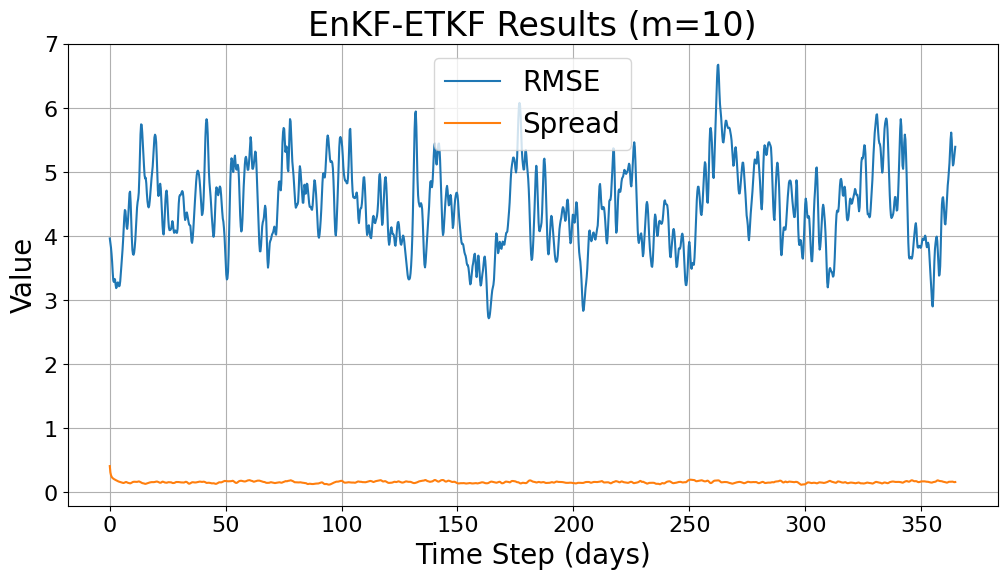

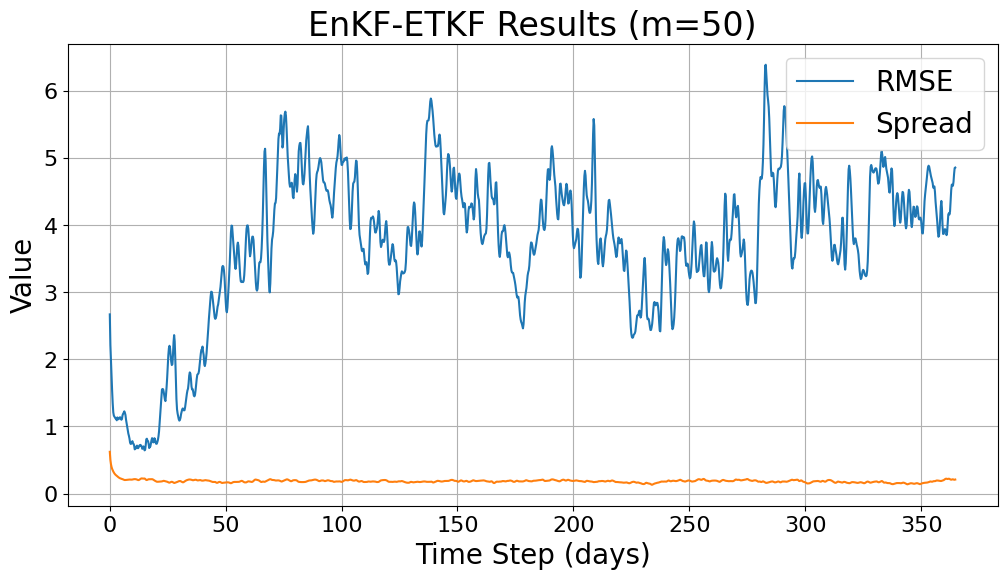

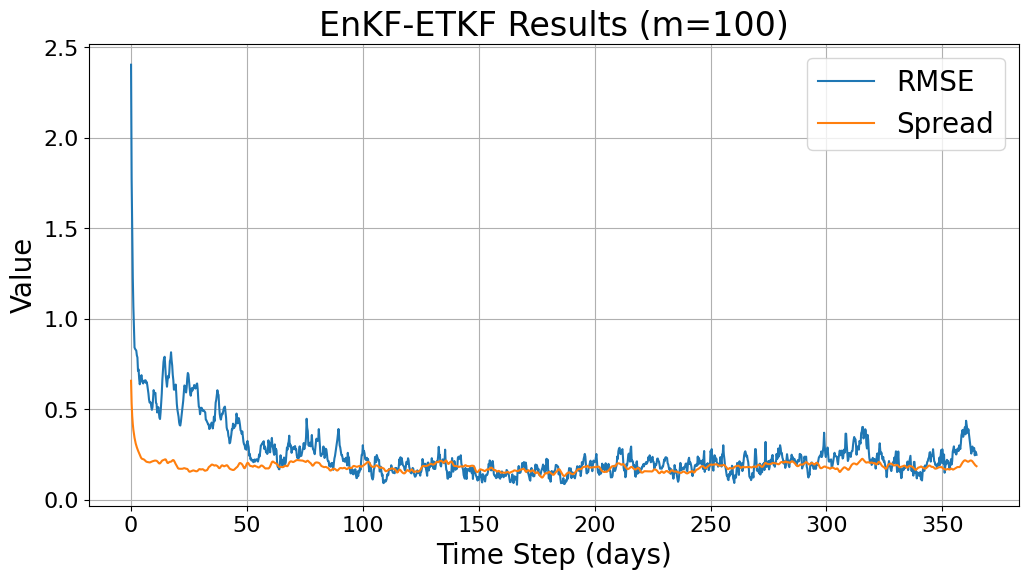

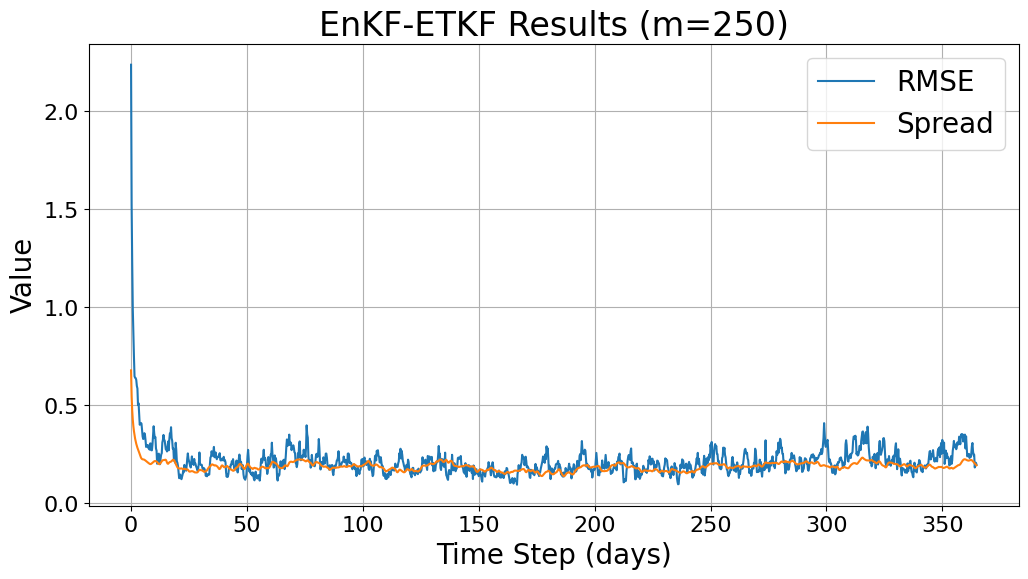

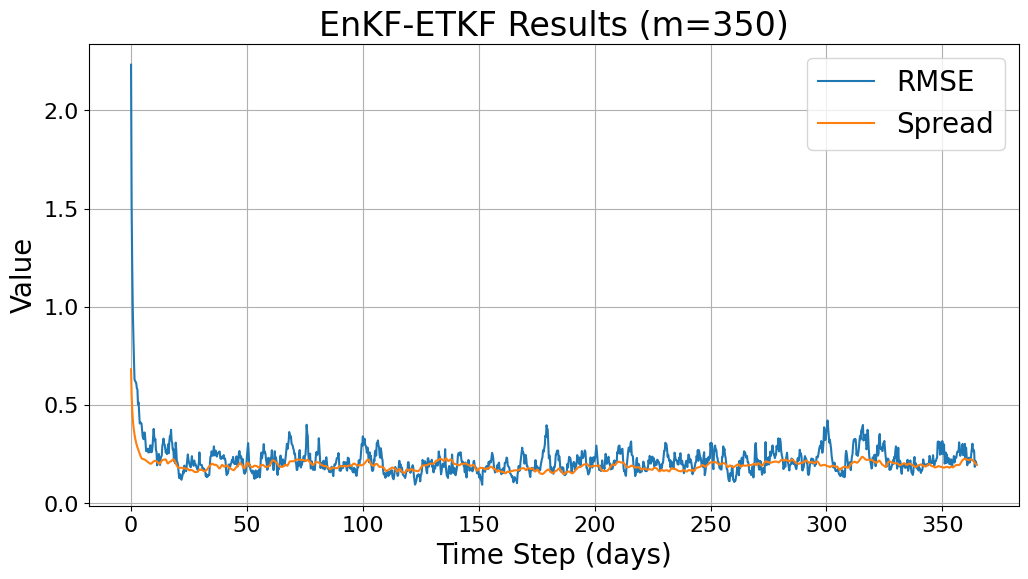

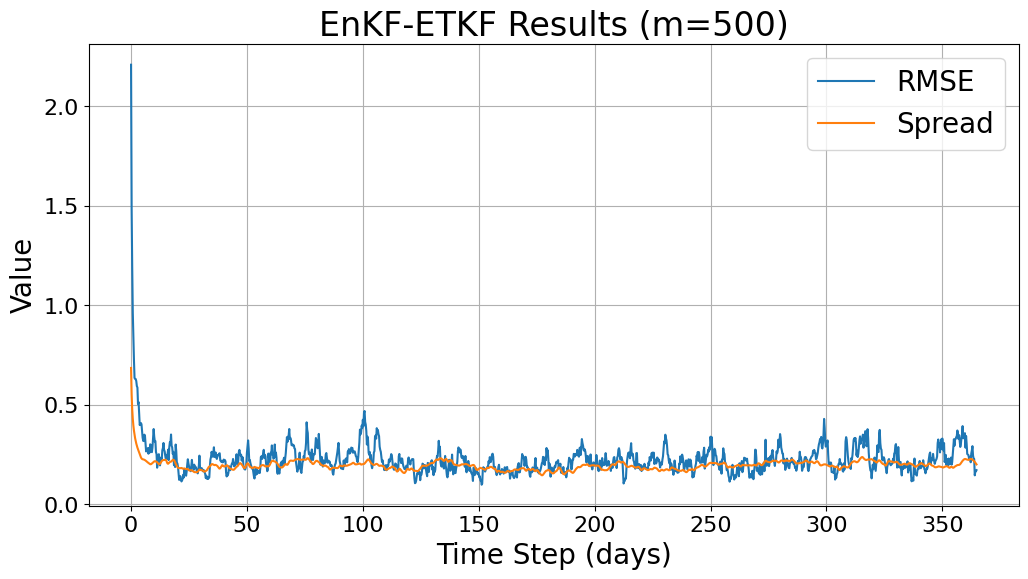

In [ ]:
# メンバー変数m=10,100,180,500の場合でスプレッドと真値とのRMSEを図示するコード
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数

# メンバー変数のサイズリスト
member_sizes = [10, 50, 100, 250, 350, 500]

# 結果の格納用辞書
results_dict = {}

# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()

# 各メンバーサイズでEnKF-ETKFを実行
for m in member_sizes:
    enkf_ETKF = EnKF_ETKF(N=N, F=F, dt=dt, ensemble_size=m, obs_error_std=1.0)
    enkf_ETKF.initialize_ensemble(spinup.x.copy())
    rmse_list = []
    spread_list = []
    for t in range(0, observed_states.shape[0], steps_per_assim):
        enkf_ETKF.forecast()
        enkf_ETKF.analysis(observed_states[t])
        print(f'EnKF-ETKF with m={m}, time step {t} / {observed_states.shape[0]} completed.')
    rmse = enkf_ETKF.calculate_rmse(true_states)
    spread = enkf_ETKF.calculate_spread()
    rmse_list.append(rmse)
    spread_list.append(spread)
    results_dict[m] = {'rmse': rmse_list, 'spread': spread_list}
# 結果のプロット
days = np.arange(observed_states.shape[0]) * dt / step_day
for m in member_sizes:
    plt.figure(figsize=(12, 6))
    plt.plot(days, results_dict[m]['rmse'][0], label='RMSE')
    plt.plot(days, results_dict[m]['spread'][0], label='Spread')
    plt.title(f'EnKF-ETKF Results (m={m})', fontsize=24)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel('Time Step (days)', fontsize=20)
    plt.ylabel('Value', fontsize=20)
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()

## LETKF(Local Ensemble Transform Kalman Filter)

### LETKFの実装方針
Lorenz-96系の各格子点ごとにローカルな観測を用いたETKFを適用し、Gaspari-Cohnによる局所化とアンサンブルインフレーションを組み合わせて過少分散を抑えます。以下ではクラス実装と実験コードを示します。

In [5]:
from scipy.linalg import sqrtm
class EnKF_LETKF:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0, inflation_factor=1.02, loc_radius=5):
        """
        LETKFを初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        H: 観測行列
        R: 観測誤差共分散行列
        ensemble_size: アンサンブルのサイズ
        obs_error_std: 観測誤差の標準偏差

        """
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N,N)
        self.p = self.H.shape[0]
        self.R = R if R is not None else np.eye(self.p, self.p) * obs_error_std
        self.Z = None
        self.ensemble_mean = None
        self.ensemble_list = []
        self.P_analysis_list = []
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.ensemble = None
        self.inflation_factor = inflation_factor
        self.L = self.localization_matrix(loc_radius=loc_radius)
        self.obs_indices = np.where(np.any(self.H, axis=0))[0]

    def initialize_ensemble(self, x0):
        np.random.seed(42)  # For reproducibility
        members = [x0 + np.random.normal(0, 1, self.N) for _ in range(self.ensemble_size)]
        self.ensemble = np.column_stack(members)
        np.random.seed() # シード値の固定を解除

    def localization_matrix(self, loc_radius):
        """Gaussian Functionでの局所化行列を作成する"""
        ### グリッド間距離の計算
        L = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(self.N):
                dist = min(abs(i - j), self.N - abs(i - j))
                if dist < 2*np.sqrt(10/3)*loc_radius:
                    # exp(- (dist / loc_radius)^2 / 2)  の形でガウシアン関数を適用
                    L[i, j] = np.exp(-0.5 * (dist / loc_radius) ** 2)
                else:
                    L[i, j] = 0.0
        return L
                    
    def forecast(self):
        """アンサンブルの予測ステップを実行する"""
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = self.step_model(self.ensemble[:, i])
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - self.ensemble_mean) / np.sqrt(self.ensemble_size - 1)
    def step_model(self, x):
        """モデルの1ステップ予測を実行する"""
        return rk4_step(x, self.F, self.dt)

    def analysis(self, observation):
        """アンサンブルの解析ステップを実行する"""
        # (1) Preparation Step
        # Zb = self.Z * np.sqrt(self.inflation_factor)
        Zb = self.Z * self.inflation_factor
        Yb = self.H @ Zb
        diff = self.H @ observation.reshape(-1, 1) - self.H @ self.ensemble_mean
        # (2) Local Analysis Step
        L = self.L # 局所化行列の取得
        Xa = np.zeros_like(self.ensemble)
        # Rの逆行列を事前に計算
        R_inv = np.linalg.inv(self.R)
        for i in range(self.N):
            # (2.1) Eigenvalue Decomposition with Localization
            # 局所化行列の取得
            loc_weights = L[i, :]
            loc_weights_obs = loc_weights[self.obs_indices]          # 長さ = 観測次元
            R_loc_inv = R_inv * loc_weights_obs[:, None]
            Pa_tilde_inv = np.eye(self.ensemble_size) + Yb.T @ R_loc_inv @ Yb
            D, C = np.linalg.eigh(Pa_tilde_inv)
            D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
            Pa_tilde = C @ np.diag(1.0 / D) @ C.T
            pa_tilde_sqrt = C @ D_inv_sqrt @ C.T
            # (2.2) Update Ensemble
            T = Pa_tilde @ Yb.T @ R_loc_inv @ diff + np.sqrt(self.ensemble_size - 1)* pa_tilde_sqrt
            Xa[i, :] = self.ensemble_mean[i, 0] + Zb[i, :] @ T
        # (3) Collect analysis Ensemble of all model grid points
        self.ensemble = Xa
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Za = (self.ensemble - self.ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        
        self.P_analysis_list.append((Za @ Za.T).copy().T)
        self.ensemble_list.append(self.ensemble.copy().T)
            

    def calculate_rmse(self, true_states):
        ensemble_mean = np.mean(self.ensemble_list, axis=1)
        rmse = ensemble_mean - true_states
        return np.sqrt(np.mean(rmse**2, axis=1))

    def calculate_spread(self):
        spread_list = []
        for P_analysis in self.P_analysis_list:
            spread = np.sqrt(np.trace(P_analysis) / self.N)
            spread_list.append(spread)
        return spread_list
           




#### LETKFの数値実験
ETKFと同じ設定でメンバー数を変化させつつ、局所化半径とインフレーションを固定して性能を比較します。

Random steps for spinup: 1126
LETKF with m=8, time step 0 / 1460 completed.
LETKF with m=8, time step 10 / 1460 completed.
LETKF with m=8, time step 20 / 1460 completed.
LETKF with m=8, time step 30 / 1460 completed.
LETKF with m=8, time step 40 / 1460 completed.
LETKF with m=8, time step 50 / 1460 completed.
LETKF with m=8, time step 60 / 1460 completed.
LETKF with m=8, time step 70 / 1460 completed.
LETKF with m=8, time step 80 / 1460 completed.
LETKF with m=8, time step 90 / 1460 completed.
LETKF with m=8, time step 100 / 1460 completed.
LETKF with m=8, time step 110 / 1460 completed.
LETKF with m=8, time step 120 / 1460 completed.
LETKF with m=8, time step 130 / 1460 completed.
LETKF with m=8, time step 140 / 1460 completed.
LETKF with m=8, time step 150 / 1460 completed.
LETKF with m=8, time step 160 / 1460 completed.
LETKF with m=8, time step 170 / 1460 completed.
LETKF with m=8, time step 180 / 1460 completed.
LETKF with m=8, time step 190 / 1460 completed.
LETKF with m=8, time 

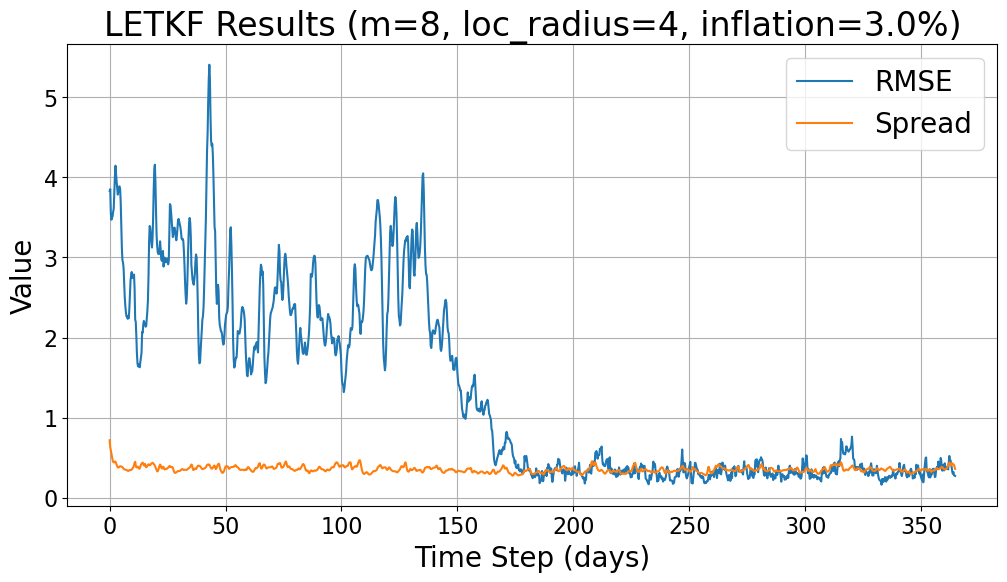

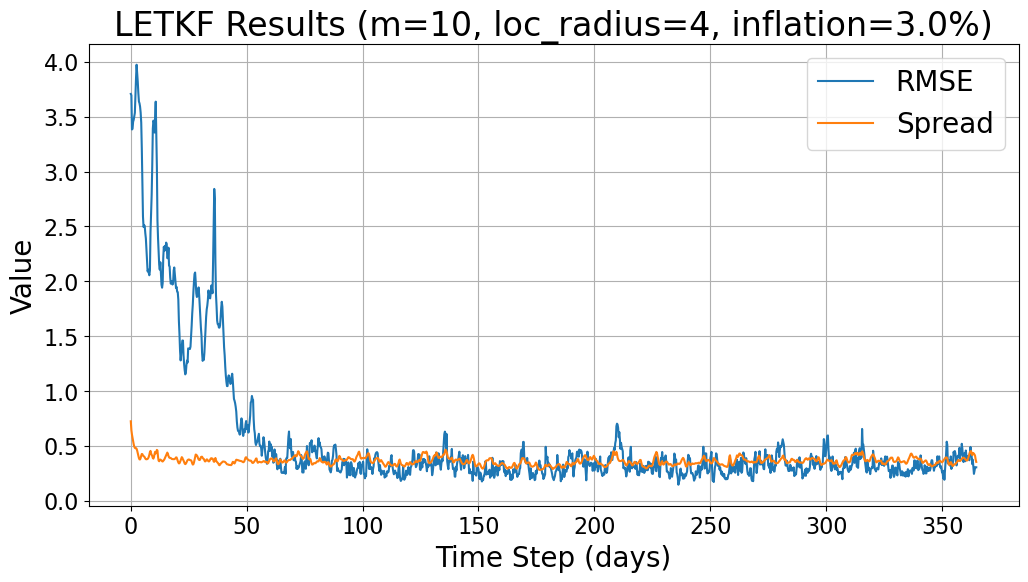

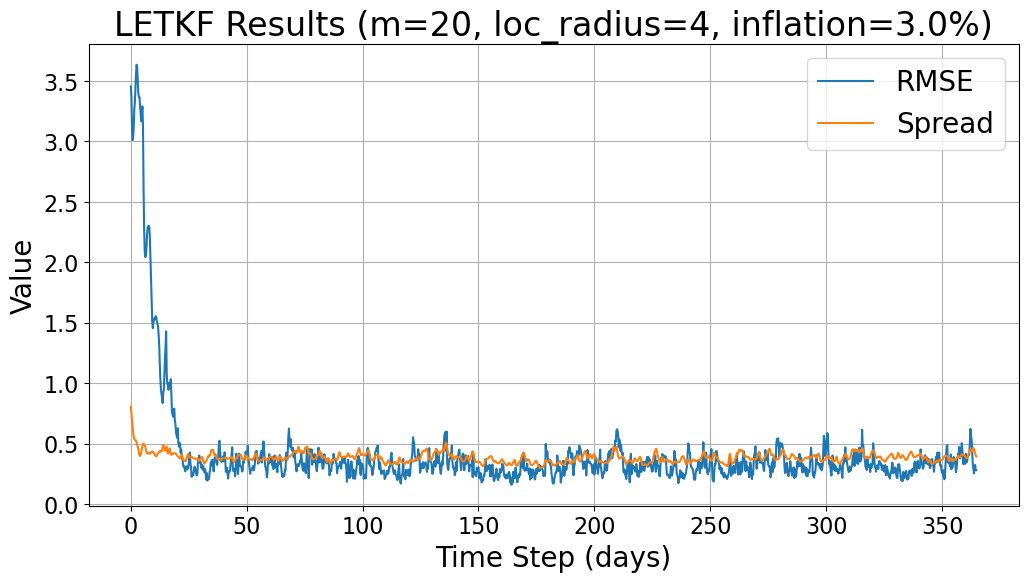

In [51]:
# LETKF experiments matching the ETKF settings
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')
N = 40
F = 8.0
dt = 0.05
step_day = 0.2
assim_interval = 0.05
steps_per_assim = int(assim_interval / dt)
member_sizes = [8, 10, 20]
loc_radius = 4
inflation_factor = 1.03
results_dict = {}
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed()
for m in member_sizes:
    H = make_homogeneous_H(N, p=20)
    letkf = EnKF_LETKF(N=N, F=F, dt=dt, H=H, ensemble_size=m, obs_error_std=1.0, loc_radius=loc_radius, inflation_factor=inflation_factor)
    letkf.initialize_ensemble(spinup.x.copy())
    rmse_list = []
    spread_list = []
    for t in range(0, observed_states.shape[0], steps_per_assim):
        letkf.forecast()
        letkf.analysis(observed_states[t])
        if (t // steps_per_assim) % 10 == 0:
            print(f'LETKF with m={m}, time step {t} / {observed_states.shape[0]} completed.')
    rmse = letkf.calculate_rmse(true_states)
    spread = letkf.calculate_spread()
    rmse_list.append(rmse)
    spread_list.append(spread)
    results_dict[m] = {'rmse': rmse_list, 'spread': spread_list}
days = np.arange(observed_states.shape[0]) * dt / step_day
for m in member_sizes:
    plt.figure(figsize=(12, 6))
    plt.plot(days, results_dict[m]['rmse'][0], label='RMSE')
    plt.plot(days, results_dict[m]['spread'][0], label='Spread')
    plt.title(f'LETKF Results (m={m}, loc_radius={loc_radius}, inflation={(inflation_factor-1)*100:.1f}%)', fontsize=24)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel('Time Step (days)', fontsize=20)
    plt.ylabel('Value', fontsize=20)
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()

#### 観測地点数による比較

In [53]:
# 縦軸inflation係数、横軸を局所化半径としててRMSEの平均値を色で表すヒートマップを作成するコード
import numpy as np
import seaborn as sns
from joblib import Parallel, delayed
import itertools

inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(2, 21)]  # 1から10.0まで0.5刻み
rmse_matrix = np.zeros((len(inflation_factors), len(loc_radius_list)))
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数
member_size = 8  # メンバー数を固定
num_obs = 20  # 観測点の数
# 結果の格納用辞書
results_dict = {}
# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(38)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed() # シード値の固定を解除

# # まずは、inflation_factor=1.05、loc_radius=5.0で動作確認
# H = make_homogeneous_H(n=N, p=num_obs)
# enkf_serial_ensrf_test = EnKF_LETKF(N=N, F=F, H=H, dt=dt, ensemble_size=member_size, obs_error_std=1.0, inflation_factor=1.05, loc_radius=5.0)
# enkf_serial_ensrf_test.initialize_ensemble(spinup.x.copy())
# for t in range(0, observed_states.shape[0], steps_per_assim):
#     enkf_serial_ensrf_test.forecast()
#     enkf_serial_ensrf_test.analysis(observed_states[t])
#     print(f'Test run: EnKF-SerialEnSRF with m={member_size}, loc_radius={5.0}, inflation={5.0}%, time step {t} / {observed_states.shape[0]} completed.')
# rmse_test = enkf_serial_ensrf_test.calculate_rmse(true_states)
# spread_test = enkf_serial_ensrf_test.calculate_spread()
# print("Test run completed.")


# 1回のシミュレーションを実行するワーカー関数
def run_simulation(inflation_factor, loc_radius):
    # スピンアップ後の初期状態をコピーして使用
    initial_state = spinup.x.copy()
    H = make_homogeneous_H(n=N, p=num_obs)
    enkf_serial_ensrf = EnKF_LETKF(N=N, F=F, H=H, dt=dt, ensemble_size=member_size, obs_error_std=1.0, inflation_factor=inflation_factor, loc_radius=loc_radius)
    enkf_serial_ensrf.initialize_ensemble(initial_state)
    
    for t in range(0, observed_states.shape[0], steps_per_assim):
        enkf_serial_ensrf.forecast()
        enkf_serial_ensrf.analysis(observed_states[t])
        print(f'EnKF-SerialEnSRF with m={member_size}, loc_radius={loc_radius}, inflation={(inflation_factor-1)*100:.1f}%, time step {t} / {observed_states.shape[0]} completed.')

    rmse = enkf_serial_ensrf.calculate_rmse(true_states)
    spread = enkf_serial_ensrf.calculate_spread()
    
    # 10日目から300日目までの平均RMSEを計算
    # start_idx = int(10 * (step_day / dt) / steps_per_assim)
    # end_idx = int(300 * (step_day / dt) / steps_per_assim) + 1
    # avg_rmse = np.mean(rmse[start_idx:end_idx])
    
    # 90日目から365日目までの平均RMSEを計算
    start_idx = int(90 * (step_day / dt) / steps_per_assim)
    end_idx = int(365 * (step_day / dt) / steps_per_assim) -1
    avg_rmse = np.mean(rmse[start_idx:end_idx])
    
    print(f'Finished: inflation={inflation_factor}, loc_radius={loc_radius}, Avg RMSE={avg_rmse:.4f}')
    
    return inflation_factor, loc_radius, avg_rmse, [rmse], [spread]

# パラメータの全組み合わせを生成
param_combinations = list(itertools.product(inflation_factors, loc_radius_list))

# n_jobs=-1 は利用可能な全てのCPUコアを使用することを意味します
results = Parallel(n_jobs=-1)(delayed(run_simulation)(inf, loc) for inf, loc in param_combinations)

# 並列実行の結果を集約
inf_map = {val: i for i, val in enumerate(inflation_factors)}
loc_map = {val: j for j, val in enumerate(loc_radius_list)}

for inflation_factor, loc_radius, avg_rmse, rmse_list, spread_list in results:
    i = inf_map[inflation_factor]
    j = loc_map[loc_radius]
    rmse_matrix[i, j] = avg_rmse
    results_dict[(inflation_factor, loc_radius)] = {'rmse': rmse_list, 'spread': spread_list}

# rmse_matrixの保存
with open(f'enkf_letkf_rmse_matrix_m{member_size}_p{num_obs}.npy', 'wb') as f:
    np.save(f, rmse_matrix)

Random steps for spinup: 1441


KeyboardInterrupt: 

RMSE Matrix:
[[3.80161689 0.72486593 0.53574325 0.58673421 1.42181447 2.61685483
  3.13810101 3.5963689  3.9443096  3.92085295 4.1714865  4.15738452
  4.10199961 4.2563726  4.60910087 4.53320272 4.62887001 4.53595326
  4.65961467 4.81605129 4.72954216]
 [3.9050406  0.72244422 0.50836339 0.45490951 0.52104809 0.42168472
  2.6272723  3.45977904 3.28102382 3.79174229 3.9513325  3.93534036
  4.13279761 4.28985135 4.3310234  4.51415347 4.25120837 4.41457838
  4.46514024 4.50195594 4.35474187]
 [3.88320043 0.65076515 0.50047104 0.42096    0.42410515 0.42834396
  0.48348229 1.46035804 3.13649628 3.52352535 3.47305783 3.71383181
  4.28074009 3.73760928 4.29611235 4.47036728 4.71758529 4.30246439
  4.49162502 4.15077045 4.67983261]
 [3.90523301 0.64301703 0.51113803 0.43301369 0.39752553 0.37971752
  0.50634637 0.45391254 2.46016463 2.95067465 3.66293617 3.85374615
  4.13017073 4.14662697 4.08693491 4.41192509 4.02737141 4.59911483
  4.23789389 4.69965418 4.73991465]
 [3.93974132 0.62238592 0.5

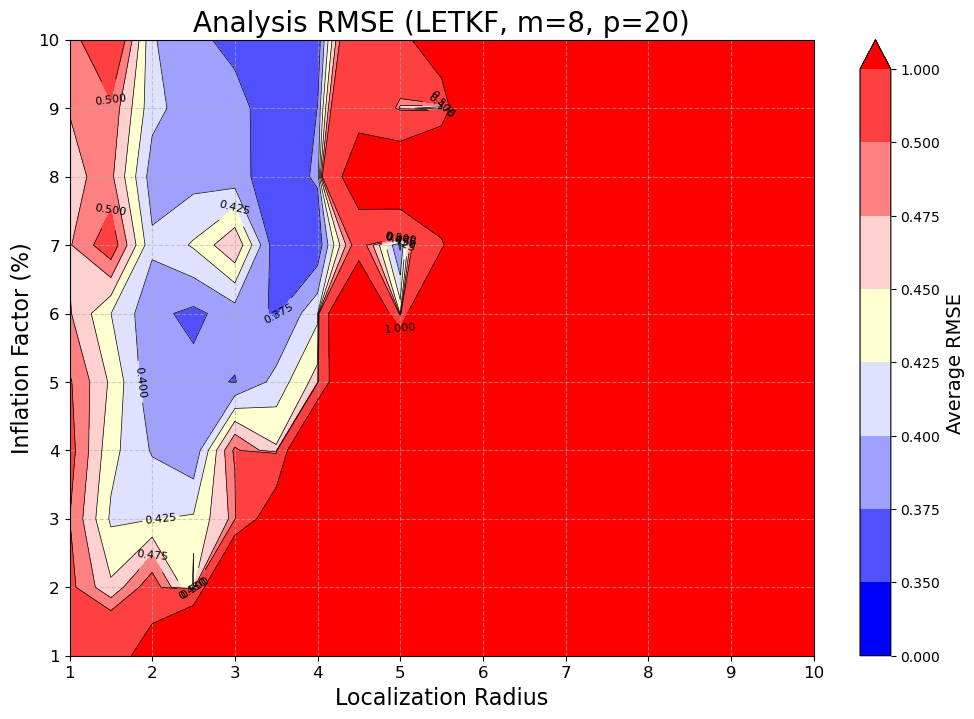

In [ ]:
# データの読み込み
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

member_size = 8  # メンバー数を固定
n_obs = 20  # 観測変数の数

with open(f'enkf_letkf_rmse_matrix_m{member_size}_p{n_obs}.npy', 'rb') as f:
    rmse_matrix = np.load(f)

# rmse_matrixを出力
print("RMSE Matrix:")
print(rmse_matrix)

# パラメータリスト
inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(0, 21)]  # 0.0から10.0まで0.5刻み

# 1. 色と境界値の定義
colors = ['#0000ff', '#5050ff', '#a0a0ff', '#e0e0ff', '#ffffd0', '#ffd0d0', '#ff8080', '#ff4040', '#ff0000']
bounds = [0, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5, 1]

# 2. カスタムカラーマップと正規化オブジェクトを作成
cmap = ListedColormap(colors)
cmap.set_over('#ff0000') # 1.0を超える値を赤色に設定
norm = BoundaryNorm(bounds, cmap.N, extend='max')

# 3. メッシュグリッドの作成
X, Y = np.meshgrid(loc_radius_list, [(inf-1)*100 for inf in inflation_factors])

# 4. 等高線図の描画
plt.figure(figsize=(12, 8))

# 塗りつぶし等高線
contourf = plt.contourf(X, Y, rmse_matrix, levels=bounds, cmap=cmap, norm=norm, extend='max')

# 等高線
contour = plt.contour(X, Y, rmse_matrix, levels=bounds, colors='black', linewidths=0.5)

# 等高線ラベル
plt.clabel(contour, inline=True, fontsize=8, fmt='%1.3f')

# カラーバー
cbar = plt.colorbar(contourf, ticks=bounds)
cbar.set_label('Average RMSE', fontsize=14)

# タイトルと軸ラベル
plt.title(f'Analysis RMSE (LETKF, m={member_size}, p={n_obs})', fontsize=20)
plt.xlabel('Localization Radius', fontsize=16)
plt.ylabel('Inflation Factor (%)', fontsize=16)

# 描画範囲の設定
plt.xlim(1, 10)

# 軸の目盛り設定
plt.xticks(np.arange(1, 11, 1), fontsize=12)
plt.yticks(np.arange(1, 11, 1), fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 局所化

局所化とは、データ同化において、観測データが影響を与える範囲を制限する手法である。アンサンブルデータ同化ではメンバー数が少ないと統計的に無関係なはずの遠く離れた地点同士で偽の相関が生じることがある。これを防ぐために、局所化を行い、観測データが影響を与える範囲を限定することで、より正確なデータ同化を実現する。

#### PO法の場合

PO法において局所化する際はCovariance localizationを用いる。Covariance Localizationでは、アンサンブルから計算される誤差共分散行列に対して、距離に基づくGaspari-Cohn関数などのローカライゼーション関数を適用し、遠く離れた地点間の相関を減少させる。

In [31]:
# PO法で局所化を導入したEnKFを実装するクラス
class EnKF_PO_Localized:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0, inflation_factor=1.0, loc_radius=5):
        """
        EnKFをPO法で初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        H: 観測行列
        R: 観測誤差共分散行列
        ensemble_size: アンサンブルのサイズ
        obs_error_std: 観測誤差の標準偏差
        inflation_factor: インフレーション係数
        loc_radius: 局所化半径
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N, N)
        self.R = R if R is not None else np.eye(N, N) * obs_error_std
        self.Z = None
        self.Y = None
        self.ensemble_list = []
        self.P_analysis_list = []
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.ensemble = None
        self.inflation_factor = inflation_factor
        self.loc_radius = loc_radius

    def initialize_ensemble(self, x0):
        np.random.seed(42)  # シード値を固定して再現性を確保
        members = [x0 + np.random.normal(0, 1, self.N) for _ in range(self.ensemble_size)]
        self.ensemble = np.column_stack(members)
        np.random.seed() # シード値の固定を解除

    def forecast(self):
        """
        アンサンブルの予報ステップを実行するメソッド
        """
        if self.ensemble is None:
            raise RuntimeError("initialize_ensemble を先に実行してください。")
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = rk4_step(self.ensemble[:, i], self.F, self.dt)
        ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        self.Y = self.H @ self.Z
    
    def localization_matrix(self, loc_radius):
        """
        Gaspari-Cohn関数を用いて局所化行列を生成するメソッド
        loc_radius: 局所化の半径
        """
        L = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(self.N):
                dist = min(abs(i - j), self.N - abs(i - j))
                r = dist / (np.sqrt(10/3)*loc_radius)
                if r <= 1:
                    L[i, j] = 1 - (5/3)*r**2 + (5/8)*r**3 + (1/2)*r**4 - (1/4)*r**5
                elif r <= 2:
                    L[i, j] = (4 - 5*r + (5/3)*r**2 + (5/8)*r**3 - (1/2)*r**4 + (1/12)*r**5)
                else:
                    L[i, j] = 0
        return L


    def analysis(self, observation):
        """
        アンサンブルの解析ステップを実行するメソッド
        observation: 観測値の配列
        """
        Z = self.Z.copy()
        L = self.localization_matrix(loc_radius=self.loc_radius)
        K = L * (Z @ self.Y.T) @ np.linalg.inv(L * (self.Y @ self.Y.T) + self.R)
        for i in range(self.ensemble_size):
            perturbation = np.random.normal(0, self.obs_error_std, self.N)
            innovation = K @ (observation + perturbation - self.H @ self.ensemble[:,i])
            self.ensemble[:,i] += innovation
        ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Z_analysis = ((self.ensemble - ensemble_mean) / np.sqrt(self.ensemble_size - 1))
        P_analysis = Z_analysis @ Z_analysis.T
        self.P_analysis_list.append(P_analysis.copy().T)
        self.ensemble_list.append(self.ensemble.copy().T)
    def calculate_rmse(self, true_states):
        """
        RMSEを計算するメソッド
        true_states: 真の状態の配列(形状: (time_steps, N))
        戻り値: 各時間ステップでのRMSEのリスト
        """
        ensemble_mean = np.mean(self.ensemble_list, axis=1)
        rmse = ensemble_mean - true_states
        return np.sqrt(np.mean(rmse ** 2, axis=1))
        
    def calculate_spread(self): 
        """
        スプレッドを計算するメソッド
        """
        # P_analysis_listから各時点のスプレッドを計算して返す
        spread_list = []
        for P_analysis in self.P_analysis_list:
            spread = np.sqrt(np.trace(P_analysis) / self.N)
            spread_list.append(spread)
        return spread_list


Random steps for spinup: 1126
EnKF-PO Localized with m=100, loc_radius=1, inflation=10.0%, time step 0 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=1, inflation=10.0%, time step 1 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=1, inflation=10.0%, time step 2 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=1, inflation=10.0%, time step 3 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=1, inflation=10.0%, time step 4 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=1, inflation=10.0%, time step 5 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=1, inflation=10.0%, time step 6 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=1, inflation=10.0%, time step 7 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=1, inflation=10.0%, time step 8 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=1, inflation=10.0%, time step 9 / 1460 completed.
EnKF-PO Localized with m=100, loc_radius=1, inflation=10.0%,

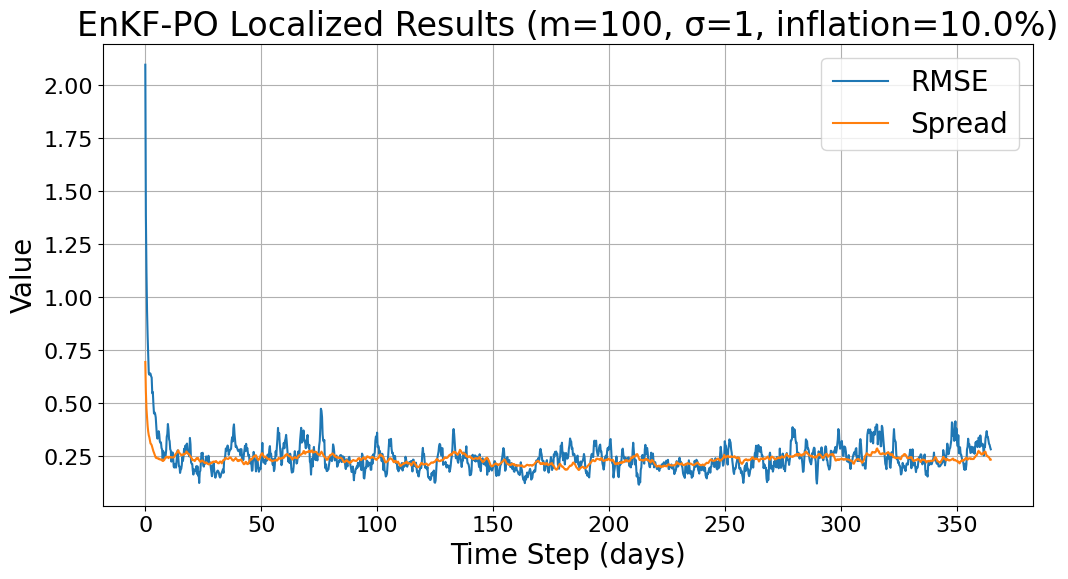

In [ ]:
# メンバー数を40、inflation_factorを1.05で固定して、局所化半径を40,10,3,1で変化させた場合のスプレッドと真値とのRMSEを図示するコード
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数
member_size = 100  # メンバー数を固定
inflation_factor = 1.05  # インフレーションファクターを固定
loc_radius_list = [1]  # 局所化半径のリスト
# 結果の格納用辞書
results_dict = {}
# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed() # シード値の固定を解除
# 各局所化半径でEnKF-POを実行
for loc_radius in loc_radius_list:
    enkf_po_loc = EnKF_PO_Localized(N=N, F=F, dt=dt, ensemble_size=member_size, obs_error_std=1.0, inflation_factor=inflation_factor, loc_radius=loc_radius)
    enkf_po_loc.initialize_ensemble(spinup.x.copy())
    rmse_list = []
    spread_list = []
    for t in range(0, observed_states.shape[0], steps_per_assim):
        enkf_po_loc.forecast()
        enkf_po_loc.analysis(observed_states[t])
        print(f'EnKF-PO Localized with m={member_size}, loc_radius={loc_radius}, inflation={(inflation_factor-1)*100:.1f}%, time step {t} / {observed_states.shape[0]} completed.')
    rmse = enkf_po_loc.calculate_rmse(true_states)
    spread = enkf_po_loc.calculate_spread()
    rmse_list.append(rmse)
    spread_list.append(spread)
    results_dict[loc_radius] = {'rmse': rmse_list, 'spread': spread_list}
# 結果のプロット
days = np.arange(observed_states.shape[0]) * dt / step_day
for loc_radius in loc_radius_list:
    plt.figure(figsize=(12, 6))
    plt.plot(days, results_dict[loc_radius]['rmse'][0], label='RMSE')
    plt.plot(days, results_dict[loc_radius]['spread'][0], label='Spread')
    plt.title(f'EnKF-PO Localized Results (m={member_size}, σ={loc_radius}, inflation={(inflation_factor-1)*100:.1f}%)', fontsize=24)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel('Time Step (days)', fontsize=20)
    plt.ylabel('Value', fontsize=20)
    plt.legend(fontsize=20)
    plt.grid()
    plt.show()


#### Serial EnSRFの場合

In [6]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Serial EnSRFを実装するクラス
class EnKF_SerialEnSRF:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0, inflation_factor=1.0, loc_radius=5):
        """
        Serial EnSRFを初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        H: 観測行列
        R: 観測誤差共分散行列
        ensemble_size: アンサンブルのサイズ
        obs_error_std: 観測誤差の標準偏差
        inflation_factor: インフレーション係数
        loc_radius: 局所化半径
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N, N)
        # Rの次元を観測次元pに合わせる
        self.p = self.H.shape[0]
        self.R = R if R is not None else np.eye(self.p) * obs_error_std
        self.Z = None
        self.Y = None
        self.ensemble_list = []
        self.P_analysis_list = []
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.ensemble = None
        self.inflation_factor = inflation_factor
        self.L = self.localization_matrix(loc_radius)

    def initialize_ensemble(self, x0):
        np.random.seed(42)  # シード値を固定して再現性を確保
        members = [x0 + np.random.normal(0, 1, self.N) for _ in range(self.ensemble_size)]
        self.ensemble = np.column_stack(members)
        np.random.seed() # シード値の固定を解除
    
    def localization_matrix(self, loc_radius):
        """
        Gaspari-Cohn関数を用いて局所化行列を生成するメソッド
        loc_radius: 局所化の半径
        """
        L = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(self.N):
                dist = min(abs(i - j), self.N - abs(i - j))
                r = dist / (np.sqrt(10/3)*loc_radius)
                if r <= 1:
                    L[i, j] = 1 - (1/4)*r**5 + (1/2)*r**4 + (5/8)*r**3 - (5/3)*r**2
                elif r <= 2:
                    L[i, j] = (1/12)*r**5 - (1/2)*r**4 + (5/8)*r**3 + (5/3)*r**2 - 5*r + 4 - (2/3)*r**-1
                else:
                    L[i, j] = 0
        return L

    def forecast(self):
        """
        アンサンブルの予報ステップを実行するメソッド
        """
        if self.ensemble is None:
            raise RuntimeError("initialize_ensemble を先に実行してください。")
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = rk4_step(self.ensemble[:, i], self.F, self.dt)
        ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - ensemble_mean) / np.sqrt(self.ensemble_size - 1)

    def analysis(self, observation):
        """
        アンサンブルの解析ステップを実行するメソッド
        observation: 観測値の配列
        """
        # Hを用いて状態ベクトルから観測値を作成
        p = self.p
        y_obs = observation

        # forecastで計算されたアンサンブルの平均を取得
        x_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        
        # Inflationはループの前に一度だけ適用
        self.Z *= self.inflation_factor # Inflationはsqrtなのか？
        self.Y = self.H @ self.Z
        
        # 局所化行列Lを事前に計算
        L = self.L
        
        for k in range(p):
            row = self.H[k, :]
            if np.count_nonzero(row) == 0:
                continue
            obs_idx_k = np.flatnonzero(row)[0]
            loc_vec = L[:, obs_idx_k]
            pf = self.Z @ self.Y[k, :].T                 # cross-cov (N,)
            sk = (self.Y[k, :] @ self.Y[k, :].T) + self.R[k, k]
            K_localized = (loc_vec[:, None] * pf[:, None]) / sk
            innovation = (y_obs[obs_idx_k] - (row @ x_mean)).reshape(1, 1)
            x_mean += K_localized @ innovation
            shrink = 1.0 / (1.0 + np.sqrt(self.R[k, k] / sk))
            K_tilda = K_localized * shrink
            self.Z -= K_tilda @ self.Y[k, :][None, :]
            self.Y = self.H @ self.Z
            
        
        # アンサンブルの更新
        self.ensemble = x_mean + self.Z * np.sqrt(self.ensemble_size - 1)
        # for i in range(self.ensemble_size):
        #     self.ensemble[:, i] = x_mean_analysis.ravel() + self.Z[:, i] * np.sqrt(self.ensemble_size - 1)
        ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Z_analysis = ((self.ensemble - ensemble_mean) / np.sqrt(self.ensemble_size - 1)) # アンサンブル偏差の再計算
        P_analysis = Z_analysis @ Z_analysis.T # 解析誤差共分散行列の計算
        self.P_analysis_list.append(P_analysis.copy().T)
        self.ensemble_list.append(self.ensemble.copy().T)
    
    def calculate_rmse(self, true_states):
        """
        RMSEを計算するメソッド
        true_states: 真の状態の配列(形状: (time_steps, N))
        戻り値: 各時間ステップでのRMSEのリスト
        """
        ensemble_mean = np.mean(self.ensemble_list, axis=1)
        rmse = ensemble_mean - true_states
        return np.sqrt(np.mean(rmse ** 2, axis=1))
    
    def calculate_spread(self):
        """
        スプレッドを計算するメソッド
        """
        # P_analysis_listから各時点のスプレッドを計算して返す
        spread_list = []
        for P_analysis in self.P_analysis_list:
            spread = np.sqrt(np.trace(P_analysis) / self.N)
            spread_list.append(spread)
        return spread_list

In [38]:
# 縦軸inflation係数、横軸を局所化半径としててRMSEの平均値を色で表すヒートマップを作成するコード
import numpy as np
import seaborn as sns
from joblib import Parallel, delayed
import itertools

inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(0, 21)]  # 0.0から10.0まで0.5刻み
rmse_matrix = np.zeros((len(inflation_factors), len(loc_radius_list)))
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数
member_size = 10  # メンバー数を固定
# 結果の格納用辞書
results_dict = {}
# スピンアップからランダムに初期状態を取得
spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)  # For reproducibility
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed() # シード値の固定を解除

# まずは、inflation_factor=1.05、loc_radius=5.0で動作確認
# enkf_serial_ensrf_test = EnKF_SerialEnSRF(N=N, F=F, dt=dt, ensemble_size=member_size, obs_error_std=1.0, inflation_factor=1.05, loc_radius=5.0)
# enkf_serial_ensrf_test.initialize_ensemble(spinup.x.copy())
# for t in range(0, observed_states.shape[0], steps_per_assim):
#     enkf_serial_ensrf_test.forecast()
#     enkf_serial_ensrf_test.analysis(observed_states[t])
#     print(f'Test run: EnKF-SerialEnSRF with m={member_size}, loc_radius={5.0}, inflation={5.0}%, time step {t} / {observed_states.shape[0]} completed.')
# rmse_test = enkf_serial_ensrf_test.calculate_rmse(true_states)
# spread_test = enkf_serial_ensrf_test.calculate_spread()
# print("Test run completed.")


# 1回のシミュレーションを実行するワーカー関数
def run_simulation(inflation_factor, loc_radius):
    # スピンアップ後の初期状態をコピーして使用
    initial_state = spinup.x.copy()
    
    enkf_serial_ensrf = EnKF_SerialEnSRF(N=N, F=F, dt=dt, ensemble_size=member_size, obs_error_std=1.0, inflation_factor=inflation_factor, loc_radius=loc_radius)
    enkf_serial_ensrf.initialize_ensemble(initial_state)
    
    for t in range(0, observed_states.shape[0], steps_per_assim):
        enkf_serial_ensrf.forecast()
        enkf_serial_ensrf.analysis(observed_states[t])
        print(f'EnKF-SerialEnSRF with m={member_size}, loc_radius={loc_radius}, inflation={(inflation_factor-1)*100:.1f}%, time step {t} / {observed_states.shape[0]} completed.')

    rmse = enkf_serial_ensrf.calculate_rmse(true_states)
    spread = enkf_serial_ensrf.calculate_spread()
    
    # 10日目から300日目までの平均RMSEを計算
    # start_idx = int(10 * (step_day / dt) / steps_per_assim)
    # end_idx = int(300 * (step_day / dt) / steps_per_assim) + 1
    # avg_rmse = np.mean(rmse[start_idx:end_idx])
    
    # 100日目から300日目までの平均RMSEを計算するように変更
    start_idx = int(100 * (step_day / dt) / steps_per_assim)
    end_idx = int(300 * (step_day / dt) / steps_per_assim) + 1
    avg_rmse = np.mean(rmse[start_idx:end_idx])
    
    # 90日目から365日目までの平均RMSEを計算するように変更
    start_idx = int(90 * (step_day / dt) / steps_per_assim)
    end_idx = int(365 * (step_day / dt) / steps_per_assim) - 1
    avg_rmse = np.mean(rmse[start_idx:end_idx])
    
    print(f'Finished: inflation={inflation_factor}, loc_radius={loc_radius}, Avg RMSE={avg_rmse:.4f}')
    
    return inflation_factor, loc_radius, avg_rmse, [rmse], [spread]

# パラメータの全組み合わせを生成
param_combinations = list(itertools.product(inflation_factors, loc_radius_list))

# n_jobs=-1 は利用可能な全てのCPUコアを使用することを意味します
results = Parallel(n_jobs=-1)(delayed(run_simulation)(inf, loc) for inf, loc in param_combinations)

# 並列実行の結果を集約
inf_map = {val: i for i, val in enumerate(inflation_factors)}
loc_map = {val: j for j, val in enumerate(loc_radius_list)}

for inflation_factor, loc_radius, avg_rmse, rmse_list, spread_list in results:
    i = inf_map[inflation_factor]
    j = loc_map[loc_radius]
    rmse_matrix[i, j] = avg_rmse
    results_dict[(inflation_factor, loc_radius)] = {'rmse': rmse_list, 'spread': spread_list}

# rmse_matrixの保存
with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}.npy', 'wb') as f:
    np.save(f, rmse_matrix)

Random steps for spinup: 1126


RMSE Matrix:
[[3.80422867 0.37374562 0.32047329 0.26749786 0.24626013 0.22849198
  0.22350083 0.96760689 1.28994894 3.22179942 3.41212163 3.3761088
  3.7390783  3.65871895 3.78089657 3.55299902 3.81985043 4.00583263
  4.04143037 4.11163879 3.95900565]
 [3.85237773 0.36894591 0.31219537 0.26369343 0.24379261 0.22793605
  0.21721522 0.21244042 0.20860121 0.20092896 0.22421537 1.29429801
  2.9379426  1.32179226 3.53517373 3.24621563 3.55000992 3.71067146
  4.04898185 3.85884906 4.16622785]
 [3.93264604 0.36147809 0.30665303 0.2655425  0.2424512  0.22810716
  0.22110496 0.2140085  0.20982415 0.20227816 0.20133362 0.82893984
  0.21825185 1.54324666 1.47673517 3.1341806  3.31474087 3.60175324
  3.82623212 3.61262084 3.76715214]
 [4.08101826 0.36755901 0.30913326 0.2718974  0.25051286 0.23773436
  0.22759635 0.22042326 0.21398087 0.21123721 0.20714099 0.21119934
  0.2072903  1.04537045 0.59546518 0.6058273  2.57179389 3.0721671
  2.95550597 3.33349506 3.44928605]
 [4.42195345 0.3686759  0.311

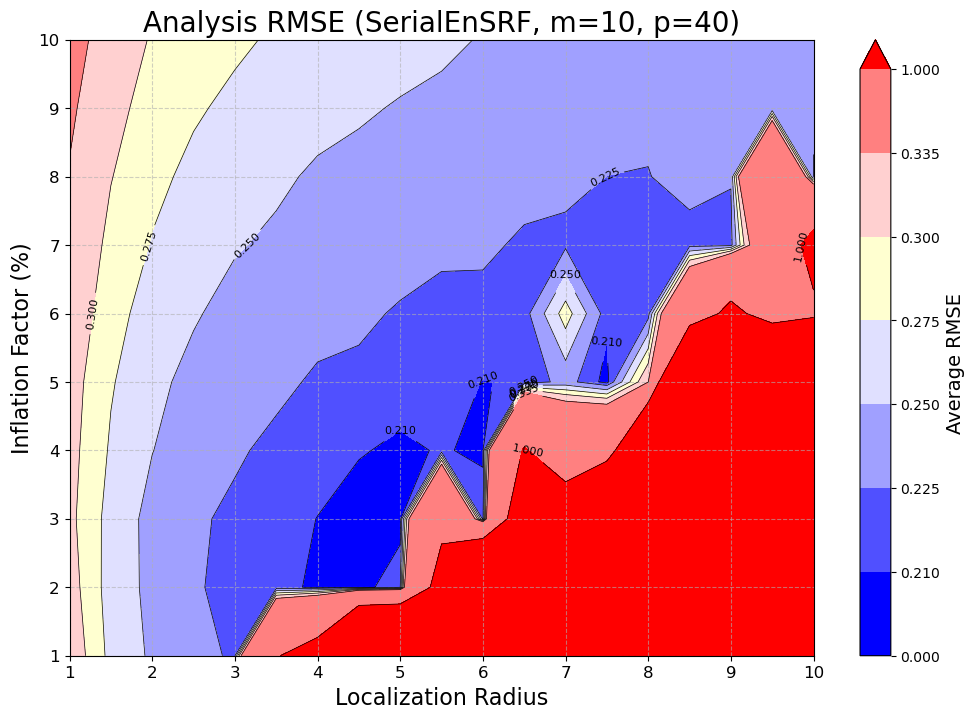

In [39]:
# データの読み込み
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

member_size = 10  # メンバー数を固定
n_obs = 40  # 観測変数の数

with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}.npy', 'rb') as f:
    rmse_matrix = np.load(f)

# rmse_matrixを出力
print("RMSE Matrix:")
print(rmse_matrix)

# パラメータリスト
inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(0, 21)]  # 0.0から10.0まで0.5刻み

# 1. 色と境界値の定義
colors = ['#0000ff', '#5050ff', '#a0a0ff', '#e0e0ff', '#ffffd0', '#ffd0d0', '#ff8080', '#ff4040', '#ff0000']
bounds = [0, 0.21, 0.225, 0.25, 0.275, 0.3, 0.335, 1]

# 2. カスタムカラーマップと正規化オブジェクトを作成
cmap = ListedColormap(colors)
cmap.set_over('#ff0000') # 1.0を超える値を赤色に設定
norm = BoundaryNorm(bounds, cmap.N, extend='max')

# 3. メッシュグリッドの作成
X, Y = np.meshgrid(loc_radius_list, [(inf-1)*100 for inf in inflation_factors])

# 4. 等高線図の描画
plt.figure(figsize=(12, 8))

# 塗りつぶし等高線
contourf = plt.contourf(X, Y, rmse_matrix, levels=bounds, cmap=cmap, norm=norm, extend='max')

# 等高線
contour = plt.contour(X, Y, rmse_matrix, levels=bounds, colors='black', linewidths=0.5)

# 等高線ラベル
plt.clabel(contour, inline=True, fontsize=8, fmt='%1.3f')

# カラーバー
cbar = plt.colorbar(contourf, ticks=bounds)
cbar.set_label('Average RMSE', fontsize=14)

# タイトルと軸ラベル
plt.title(f'Analysis RMSE (SerialEnSRF, m={member_size}, p={n_obs})', fontsize=20)
plt.xlabel('Localization Radius', fontsize=16)
plt.ylabel('Inflation Factor (%)', fontsize=16)

# 描画範囲の設定
plt.xlim(1, 10)

# 軸の目盛り設定
plt.xticks(np.arange(1, 11, 1), fontsize=12)
plt.yticks(np.arange(1, 11, 1), fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 観測地点数による比較

###### 観測地点が一様に分布している場合

In [7]:
# 縦軸inflation係数、横軸を局所化半径としててRMSEの平均値を色で表すヒートマップを作成するコード
import numpy as np
import seaborn as sns
from joblib import Parallel, delayed
import itertools

inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(0, 21)]  # 0.0から10.0まで0.5刻み
rmse_matrix = np.zeros((len(inflation_factors), len(loc_radius_list)))
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数
member_size = 8  # メンバー数を固定
num_obs_list = [20, 25, 30, 35, 40]  # 観測点数の候補

spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed()

for num_obs in num_obs_list:
    print(f"==== num_obs={num_obs} ====")
    H = make_homogeneous_H(n=N, p=num_obs)
    rmse_matrix = np.zeros((len(inflation_factors), len(loc_radius_list)))
    results_dict = {}

    def run_simulation(inflation_factor, loc_radius):
        initial_state = spinup.x.copy()
        enkf_serial_ensrf = EnKF_SerialEnSRF(
            N=N, F=F, dt=dt,
            ensemble_size=member_size,
            obs_error_std=1.0,
            H=H,
            inflation_factor=inflation_factor,
            loc_radius=loc_radius
        )
        enkf_serial_ensrf.initialize_ensemble(initial_state)

        for t in range(0, observed_states.shape[0], steps_per_assim):
            enkf_serial_ensrf.forecast()
            enkf_serial_ensrf.analysis(observed_states[t])

        rmse = enkf_serial_ensrf.calculate_rmse(true_states)
        spread = enkf_serial_ensrf.calculate_spread()

        # start_idx = int(100 * (step_day / dt) / steps_per_assim)
        # end_idx = int(300 * (step_day / dt) / steps_per_assim) + 1
        start_idx = int(90 * (step_day / dt) / steps_per_assim)
        end_idx = int(365 * (step_day / dt) / steps_per_assim) - 1
        avg_rmse = np.mean(rmse[start_idx:end_idx])
        return inflation_factor, loc_radius, avg_rmse, [rmse], [spread]

    param_combinations = list(itertools.product(inflation_factors, loc_radius_list))
    results = Parallel(n_jobs=-1)(
        delayed(run_simulation)(inf, loc) for inf, loc in param_combinations
    )

    inf_map = {val: i for i, val in enumerate(inflation_factors)}
    loc_map = {val: j for j, val in enumerate(loc_radius_list)}
    for inflation_factor, loc_radius, avg_rmse, rmse_list, spread_list in results:
        i = inf_map[inflation_factor]
        j = loc_map[loc_radius]
        rmse_matrix[i, j] = avg_rmse
        results_dict[(inflation_factor, loc_radius)] = {'rmse': rmse_list, 'spread': spread_list}

    with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}_p{num_obs}homogeneous.npy', 'wb') as f:
        np.save(f, rmse_matrix)

Random steps for spinup: 1126
==== num_obs=20 ====
==== num_obs=25 ====
==== num_obs=30 ====
==== num_obs=35 ====
==== num_obs=40 ====


RMSE Matrix:
[[3.82259183 0.71664725 0.55388195 0.47341339 0.41665314 0.45889105
  2.88657684 0.39839927 3.33937357 3.87341289 3.86917776 4.05756879
  4.24572089 4.3725456  4.43173127 4.56818385 4.34455078 4.3181383
  4.47009916 4.3559902  4.48901709]
 [3.91026896 0.73762481 0.5041836  0.42159598 0.39175948 0.36550087
  0.34271454 1.95386009 0.59688395 3.19860733 3.66758066 3.80354786
  3.94969187 4.17255278 4.17214148 4.26821874 4.44951043 4.73085717
  4.57352165 4.53128241 4.40960598]
 [3.9712499  0.6878667  0.48480124 0.42918495 0.39552684 0.35397253
  0.34800602 0.33815808 0.33867238 0.32460904 3.53016058 2.38234491
  3.84722079 3.94844095 3.42574159 4.23560549 4.21362704 4.28461615
  4.48058915 4.48747873 4.28453994]
 [4.14752129 0.72219395 0.48784952 0.42874251 0.40456305 0.37617958
  0.35474544 0.34565324 0.33604262 0.33182489 0.33630239 0.32417601
  1.86258003 3.94236325 3.89463011 3.64951348 4.04157631 4.0375832
  4.25909466 4.26764987 4.37454927]
 [4.49947987 0.76396078 0.491

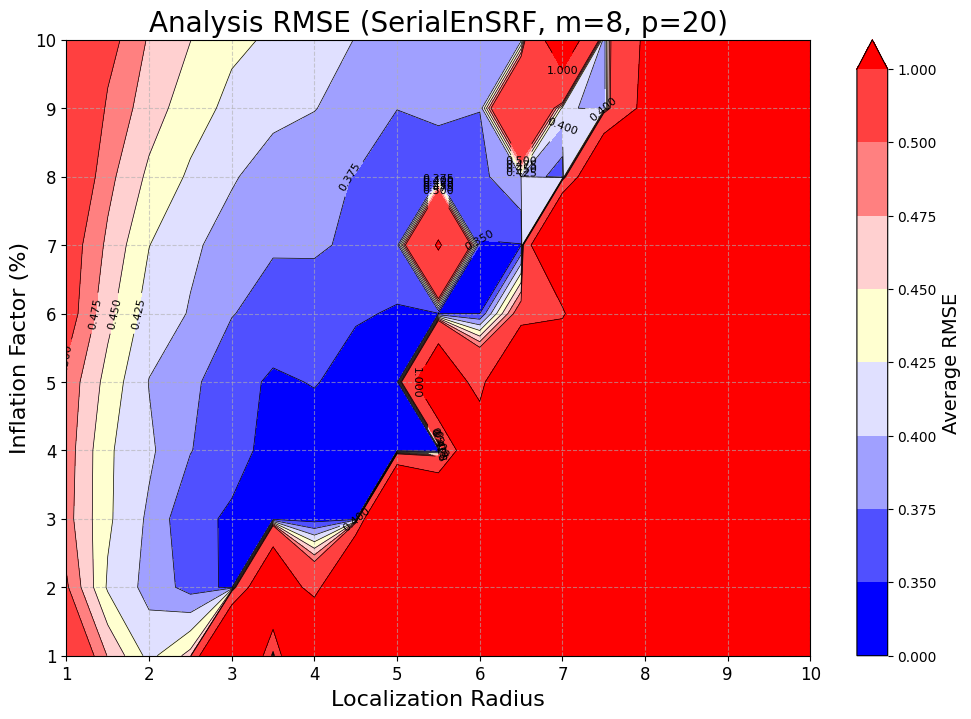

In [1]:
# データの読み込み
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

member_size = 8  # メンバー数を固定
n_obs = 20  # 観測変数の数

with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}_p{n_obs}homogeneous.npy', 'rb') as f:
    rmse_matrix = np.load(f)

# rmse_matrixを出力
print("RMSE Matrix:")
print(rmse_matrix)

# パラメータリスト
inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(0, 21)]  # 0.0から10.0まで0.5刻み

# 1. 色と境界値の定義
colors = ['#0000ff', '#5050ff', '#a0a0ff', '#e0e0ff', '#ffffd0', '#ffd0d0', '#ff8080', '#ff4040', '#ff0000']
bounds = [0, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5, 1]

# 2. カスタムカラーマップと正規化オブジェクトを作成
cmap = ListedColormap(colors)
cmap.set_over('#ff0000') # 1.0を超える値を赤色に設定
norm = BoundaryNorm(bounds, cmap.N, extend='max')

# 3. メッシュグリッドの作成
X, Y = np.meshgrid(loc_radius_list, [(inf-1)*100 for inf in inflation_factors])

# 4. 等高線図の描画
plt.figure(figsize=(12, 8))

# 塗りつぶし等高線
contourf = plt.contourf(X, Y, rmse_matrix, levels=bounds, cmap=cmap, norm=norm, extend='max')

# 等高線
contour = plt.contour(X, Y, rmse_matrix, levels=bounds, colors='black', linewidths=0.5)

# 等高線ラベル
plt.clabel(contour, inline=True, fontsize=8, fmt='%1.3f')

# カラーバー
cbar = plt.colorbar(contourf, ticks=bounds)
cbar.set_label('Average RMSE', fontsize=14)

# タイトルと軸ラベル
plt.title(f'Analysis RMSE (SerialEnSRF, m={member_size}, p={n_obs})', fontsize=20)
plt.xlabel('Localization Radius', fontsize=16)
plt.ylabel('Inflation Factor (%)', fontsize=16)

# 描画範囲の設定
plt.xlim(1, 10)

# 軸の目盛り設定
plt.xticks(np.arange(1, 11, 1), fontsize=12)
plt.yticks(np.arange(1, 11, 1), fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

###### 観測が密集している場合

In [8]:
# 縦軸inflation係数、横軸を局所化半径としててRMSEの平均値を色で表すヒートマップを作成するコード
import numpy as np
import seaborn as sns
from joblib import Parallel, delayed
import itertools

inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(0, 21)]  # 0.0から10.0まで0.5刻み
rmse_matrix = np.zeros((len(inflation_factors), len(loc_radius_list)))
# 観測データと真値の読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む
# パラメータ設定
N = 40  # 状態変数の数
F = 8.0  # 外部からの強制力
dt = 0.05  # 時間ステップ
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数
member_size = 8  # メンバー数を固定
num_obs_list = [20, 25, 30, 35, 40]  # 観測点数の候補

spinup = StateArray(N, F, dt, method='rk4')
np.random.seed(42)
random_steps = np.random.randint(0, int(365 * 0.2 / dt))
print(f"Random steps for spinup: {random_steps}")
for _ in range(random_steps):
    spinup.step()
np.random.seed()

for num_obs in num_obs_list:
    print(f"==== num_obs={num_obs} ====")
    H = make_dense_H(n=N, p=num_obs)
    rmse_matrix = np.zeros((len(inflation_factors), len(loc_radius_list)))
    results_dict = {}

    def run_simulation(inflation_factor, loc_radius):
        initial_state = spinup.x.copy()
        enkf_serial_ensrf = EnKF_SerialEnSRF(
            N=N, F=F, dt=dt,
            ensemble_size=member_size,
            obs_error_std=1.0,
            H=H,
            inflation_factor=inflation_factor,
            loc_radius=loc_radius
        )
        enkf_serial_ensrf.initialize_ensemble(initial_state)

        for t in range(0, observed_states.shape[0], steps_per_assim):
            enkf_serial_ensrf.forecast()
            enkf_serial_ensrf.analysis(observed_states[t])

        rmse = enkf_serial_ensrf.calculate_rmse(true_states)
        spread = enkf_serial_ensrf.calculate_spread()

        start_idx = int(90 * (step_day / dt) / steps_per_assim)
        end_idx = int(365 * (step_day / dt) / steps_per_assim) - 1
        avg_rmse = np.mean(rmse[start_idx:end_idx])
        return inflation_factor, loc_radius, avg_rmse, [rmse], [spread]

    param_combinations = list(itertools.product(inflation_factors, loc_radius_list))
    results = Parallel(n_jobs=-1)(
        delayed(run_simulation)(inf, loc) for inf, loc in param_combinations
    )

    inf_map = {val: i for i, val in enumerate(inflation_factors)}
    loc_map = {val: j for j, val in enumerate(loc_radius_list)}
    for inflation_factor, loc_radius, avg_rmse, rmse_list, spread_list in results:
        i = inf_map[inflation_factor]
        j = loc_map[loc_radius]
        rmse_matrix[i, j] = avg_rmse
        results_dict[(inflation_factor, loc_radius)] = {'rmse': rmse_list, 'spread': spread_list}

    with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}_p{num_obs}dense.npy', 'wb') as f:
        np.save(f, rmse_matrix)

Random steps for spinup: 1126
==== num_obs=20 ====
==== num_obs=25 ====
==== num_obs=30 ====
==== num_obs=35 ====
==== num_obs=40 ====


RMSE Matrix:
[[3.81260734 2.25790684 2.18745624 2.17241792 2.19045466 2.11359146
  2.03852989 2.1706037  2.50689942 2.54532686 2.72552841 2.72656568
  2.88142381        nan        nan        nan        nan        nan
         nan        nan        nan]
 [3.83257547 2.27981913 2.24012174 2.21112568 2.18405899 2.1000598
  2.09005767 2.17353128 2.36387248 2.62413792 2.75186542 2.64953669
         nan        nan        nan        nan        nan        nan
         nan        nan        nan]
 [3.93174996 2.36809002 2.29101833 2.18703769 2.15700411 2.1415464
  2.19421727 2.27856766 2.35438248 2.3878007  2.7232705         nan
         nan 2.75838203        nan        nan        nan        nan
         nan        nan        nan]
 [3.91326046 2.41453709 2.33419279 2.33284255 2.25094425 2.21943371
  2.23675124 2.35946872 2.25478659 2.39068346 2.35910468 2.57622304
         nan        nan        nan        nan        nan        nan
         nan        nan        nan]
 [3.92751161 2.51725902 2.446

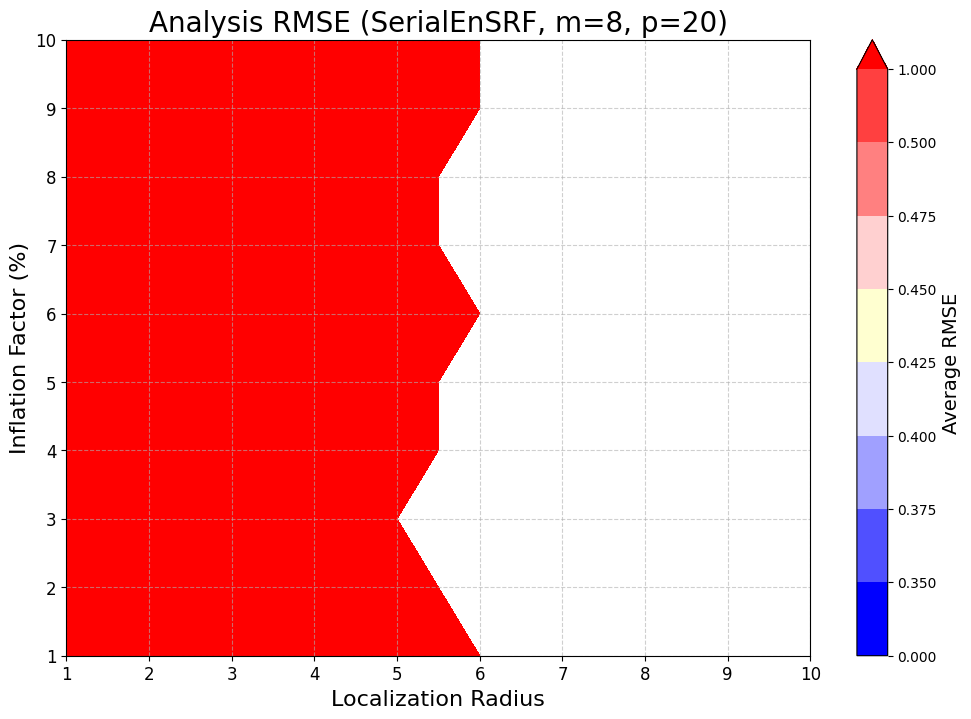

In [74]:
# データの読み込み
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

member_size = 8  # メンバー数を固定
n_obs = 20  # 観測変数の数

with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}_p{n_obs}dense.npy', 'rb') as f:
    rmse_matrix = np.load(f)

# rmse_matrixを出力
print("RMSE Matrix:")
print(rmse_matrix)

# パラメータリスト
inflation_factors = [1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09, 1.1]
loc_radius_list = [0.5 * i for i in range(0, 21)]  # 0.0から10.0まで0.5刻み

# 1. 色と境界値の定義
colors = ['#0000ff', '#5050ff', '#a0a0ff', '#e0e0ff', '#ffffd0', '#ffd0d0', '#ff8080', '#ff4040', '#ff0000']
bounds = [0, 0.35, 0.375, 0.4, 0.425, 0.45, 0.475, 0.5, 1]

# 2. カスタムカラーマップと正規化オブジェクトを作成
cmap = ListedColormap(colors)
cmap.set_over('#ff0000') # 1.0を超える値を赤色に設定
norm = BoundaryNorm(bounds, cmap.N, extend='max')

# 3. メッシュグリッドの作成
X, Y = np.meshgrid(loc_radius_list, [(inf-1)*100 for inf in inflation_factors])

# 4. 等高線図の描画
plt.figure(figsize=(12, 8))

# 塗りつぶし等高線
contourf = plt.contourf(X, Y, rmse_matrix, levels=bounds, cmap=cmap, norm=norm, extend='max')

# 等高線
contour = plt.contour(X, Y, rmse_matrix, levels=bounds, colors='black', linewidths=0.5)

# 等高線ラベル
plt.clabel(contour, inline=True, fontsize=8, fmt='%1.3f')

# カラーバー
cbar = plt.colorbar(contourf, ticks=bounds)
cbar.set_label('Average RMSE', fontsize=14)

# タイトルと軸ラベル
plt.title(f'Analysis RMSE (SerialEnSRF, m={member_size}, p={n_obs})', fontsize=20)
plt.xlabel('Localization Radius', fontsize=16)
plt.ylabel('Inflation Factor (%)', fontsize=16)

# 描画範囲の設定
plt.xlim(1, 10)

# 軸の目盛り設定
plt.xticks(np.arange(1, 11, 1), fontsize=12)
plt.yticks(np.arange(1, 11, 1), fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 観測ネットワークによる感度の比較

In [87]:
# 3DVARクラスの定義
class ThreeDVar:
    """
    3次元変分法 (3DVAR) クラス
    """
    def __init__(self, N, F, dt, obs_error_std=1.0, forecast_error_std=1.0, H=None, use_constant_P=False, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.0):
        """
        3次元変分法の初期化

        Parameters:
        -----------
        N : int
            状態変数の数
        F : float
            外部強制力
        dt : float
            時間ステップ
        H : ndarray
            観測演算子
        obs_error_std : float
            観測誤差の標準偏差
        forecast_error_std : float
            予報誤差の標準偏差(定数として使用可能)
        model_error_std : float
            モデル誤差の標準偏差
        use_constant_P : bool
            予報誤差共分散を定数として扱うか(True=3次元変分法と同値)
        method : str
            時間積分メソッド ('euler', 'rk2', 'rk4')
        way : str
            接線線形演算子の計算方法 ('Numerical', 'Mathematical')
        delta : float
            接線線形演算子の数値微分の差分幅(ヤコビ行列計算用)
        inflation_factor : float
            予報誤差共分散行列のインフレーション係数
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.obs_error_std = obs_error_std
        self.forecast_error_std = forecast_error_std
        self.H = H
        self.use_constant_P = use_constant_P
        self.method = method
        self.way = way
        self.delta = delta
        self.inflation_factor = inflation_factor

        # StateArrayクラスのインスタンス化
        self.state_array = StateArray(N, F, dt, method=method)
        
        # 観測誤差共分散行列
        self.R = obs_error_std * np.eye(N)
        
        # 予報誤差共分散行列
        self.P_analysis = forecast_error_std * np.eye(N)
        self.P_forecast = None
        self.P_constant = forecast_error_std * np.eye(N)  # 定数として保存
        
        
        # 状態変数の初期化
        self.x_analysis = None
        self.x_forecast = None
        
        # 履歴の保存
        self.analysis_history = []
        self.forecast_history = []
        self.innovation_history = []
        self.P_history = []  # 予報誤差共分散行列の履歴
        
    def initialize_state(self, x0):
        """
        初期状態の設定
        
        Parameters:
        -----------
        x0 : ndarray
            初期状態ベクトル
        """
        self.x_analysis = x0.copy()
        if self.H.any():
            self.R = self.obs_error_std * np.eye(self.H.shape[0])
        
    def compute_tangent_linear(self, x, way='Numerical'):
        """
        Lorenz96モデルの接線形演算子(ヤコビ行列)を計算
        
        Parameters:
        -----------
        x : ndarray
            状態ベクトル
            
        Returns:
        --------
        M : ndarray
            接線形演算子行列
        """
        if way == 'Numerical':
            N = len(x)
            M = np.zeros((N, N))
            e = np.eye(N)
            delta = self.delta
            temp_state = StateArray(N, self.F, self.dt, method=self.method)
            temp_state.x = x.copy()
            temp_state.step()
            f = temp_state.x.copy()
            for i in range(N):
                x_plus = x.copy()
                x_plus += delta * e[:, i]
                temp_state.x = x_plus.copy()
                temp_state.step()
                f_plus = temp_state.x.copy()

                M[:, i] = (f_plus - f) / delta
            
            return M
        
        elif way == 'Mathematical':
            N = len(x)
            M = np.zeros((N, N))
            
            for i in range(N):
                # ∂f_i/∂x_{i-2}
                M[i, i-2] = -x[i-1]
                # ∂f_i/∂x_{i-1}
                M[i, i-1] = x[(i+1)%N] - x[i-2]
                # ∂f_i/∂x_i
                M[i, i] = -1.0
                # ∂f_i/∂x_{i+1}
                M[i, (i+1)%N] = x[i-1]
            
            # 接線形演算子: I + dt*M (1次近似)
            return np.eye(N) + self.dt * M
    
    def forecast(self, steps):
        """
        予報ステップ
        
        Parameters:
        -----------
        steps : int
            時間積分のステップ数
        """

        # StateArrayを使って状態ベクトルの時間積分
        self.state_array.x = self.x_analysis.copy()
        
        for _ in range(steps):
            self.state_array.step()
        
        self.x_forecast = self.state_array.x.copy()
        
        if not self.use_constant_P:
            # 接線形演算子の計算と合成
            x_temp = self.x_analysis.copy()
            
            for _ in range(steps):
                M = self.compute_tangent_linear(x_temp, way=self.way)
                # StateArrayを使って次のステップへ
                temp_state = StateArray(self.N, self.F, self.dt, method=self.method)
                temp_state.x = x_temp.copy()
                temp_state.step()
                x_temp = temp_state.x.copy()
            
            # 予報誤差共分散行列の更新
            self.P_forecast = M @ self.P_analysis @ M.T * self.inflation_factor  # インフレーションを適用
        else:
            # 定数として扱う場合(3次元変分法と同値)
            self.P_forecast = self.P_constant.copy()
        
        self.forecast_history.append(self.x_forecast.copy())
        self.P_history.append(self.P_forecast.copy())  # 予報誤差共分散行列を保存
        
    def analysis(self, observation, H=None):
        """
        解析ステップ
        
        Parameters:
        -----------
        observation : ndarray
            観測ベクトル
        H : ndarray, optional
            観測演算子(デフォルトは単位行列=全変数を観測)
        """
        if H is None:
            H = np.eye(self.N)
        
        # カルマンゲインの計算
        HPH = H @ self.P_forecast @ H.T
        K = self.P_forecast @ H.T @ np.linalg.inv(HPH + self.R)

        # イノベーション(観測と予報の差)
        innovation = H @ observation - H @ self.x_forecast
        self.innovation_history.append(innovation.copy())
        
        # 解析値の計算
        self.x_analysis = self.x_forecast + K @ innovation
        
        if not self.use_constant_P:
            # 解析誤差共分散行列の更新
            self.P_analysis = (np.eye(self.N) - K @ H) @ self.P_forecast
        
        self.analysis_history.append(self.x_analysis.copy())
        
    def assimilate(self, observation, steps, H=None):
        """
        1サイクルのデータ同化(予報→解析)
        
        Parameters:
        -----------
        observation : ndarray
            観測ベクトル
        steps : int
            予報の時間積分ステップ数
        H : ndarray, optional
            観測演算子
        """
        self.forecast(steps)
        self.analysis(observation, H)
        
    def get_analysis_array(self):
        """解析値の履歴を配列として取得"""
        return np.array(self.analysis_history)
    
    def get_forecast_array(self):
        """予報値の履歴を配列として取得"""
        return np.array(self.forecast_history)
    
    def get_innovation_array(self):
        """イノベーションの履歴を配列として取得"""
        return np.array(self.innovation_history)
    
    def compute_rmse(self, true_states):
        """
        RMSEを計算
        
        Parameters:
        -----------
        true_states : ndarray
            真値の配列
            
        Returns:
        --------
        rmse_analysis : ndarray
            解析値のRMSE
        rmse_forecast : ndarray
            予報値のRMSE
        """
        analysis_array = self.get_analysis_array()
        forecast_array = self.get_forecast_array()
        
        rmse_analysis = np.sqrt(np.mean((analysis_array - true_states)**2, axis=1))
        rmse_forecast = np.sqrt(np.mean((forecast_array - true_states)**2, axis=1))
        
        return rmse_analysis, rmse_forecast
    
    def get_P_history(self):
        """予報誤差共分散行列の履歴を取得(保存されている場合)"""
        if hasattr(self, 'P_history'):
            return self.P_history
        else:
            return None
    
    def compute_spread(self):
        """
        Spreadを計算(予報誤差共分散行列の対角成分の平方根の平均)
        
        Returns:
        --------
        spread : ndarray
            各サイクルにおけるSpread
        """
        if hasattr(self, 'P_history') and len(self.P_history) > 0:
            spread = np.array([np.sqrt(np.trace(P)/self.N) for P in self.P_history])
            return spread
        else:
            print("Warning: P_history not available. Spread cannot be computed.")
            return None
        

In [88]:
# ETFと3DVARの観測地点数を変化させた場合の10-300daysの平均RMSEを計算し、プロットするコード
# 観測データの読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む

# パラメータ設定
N = 40
F = 8.0
dt = 0.05
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数

# Store results for all inflation factors
results_dict = {}

p_values = [20, 25, 30, 35, 40]

for p in p_values:
    print(f"\n=== Number of Observations: {p} ===")
    H = make_homogeneous_H(n=N, p=p)
    # ThreeDVarインスタンスの作成
    three_d_var = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=0.26, H=H, use_constant_P=True, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.0)
    # Extended Kalman Filterインスタンスの作成
    etf = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=1.0, H=H, use_constant_P=False, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.1)

    # 初期状態の設定
    spinup = StateArray(N, F, dt, method='rk4')
    np.random.seed(42)  # For reproducibility
    random_steps = np.random.randint(0, int(365 * 0.2 / dt))
    for _ in range(random_steps):
        spinup.step()
    three_d_var.initialize_state(spinup.x.copy())
    etf.initialize_state(spinup.x.copy())
    # データ同化の実行
    num_assim = len(observed_states)
    for k in range(num_assim):
        three_d_var.assimilate(observed_states[k], steps_per_assim, H)
        etf.assimilate(observed_states[k], steps_per_assim, H)
        if (k % 100) == 0:
            print(f"Assimilating cycle {k}/{num_assim}")
    # RMSEの計算
    rmse_analysis_3dvar, rmse_forecast_3dvar = three_d_var.compute_rmse(true_states)
    rmse_analysis_etf, rmse_forecast_etf = etf.compute_rmse(true_states)
    # 結果を保存
    results_dict[p] = {
        'rmse_analysis_3dvar': rmse_analysis_3dvar,
        'rmse_forecast_3dvar': rmse_forecast_3dvar,
        'rmse_analysis_etf': rmse_analysis_etf,
        'rmse_forecast_etf': rmse_forecast_etf
    }

# 保存したresults_dictを使って10-300daysの平均RMSEを計算し、それぞれmin_rmse_values_3dvarとmin_rmse_values_etfに格納
min_rmse_values_3dvar = []
min_rmse_values_etf = []
for p in p_values:
    data = results_dict[p]
    rmse_analysis_3dvar = data['rmse_analysis_3dvar']
    rmse_analysis_etf = data['rmse_analysis_etf']
    
    start_idx = int(10 * (step_day / dt) / steps_per_assim)
    end_idx = int(300 * (step_day / dt) / steps_per_assim) + 1
    avg_rmse_3dvar = np.mean(rmse_analysis_3dvar[start_idx:end_idx])
    avg_rmse_etf = np.mean(rmse_analysis_etf[start_idx:end_idx])
    min_rmse_values_3dvar.append(avg_rmse_3dvar)
    min_rmse_values_etf.append(avg_rmse_etf)


=== Number of Observations: 20 ===
Assimilating cycle 0/1460
Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460

=== Number of Observations: 25 ===
Assimilating cycle 0/1460
Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460

=== Number of Observations: 30 ===
Assimilating cycle 0/1460
Assimilating cycle 1

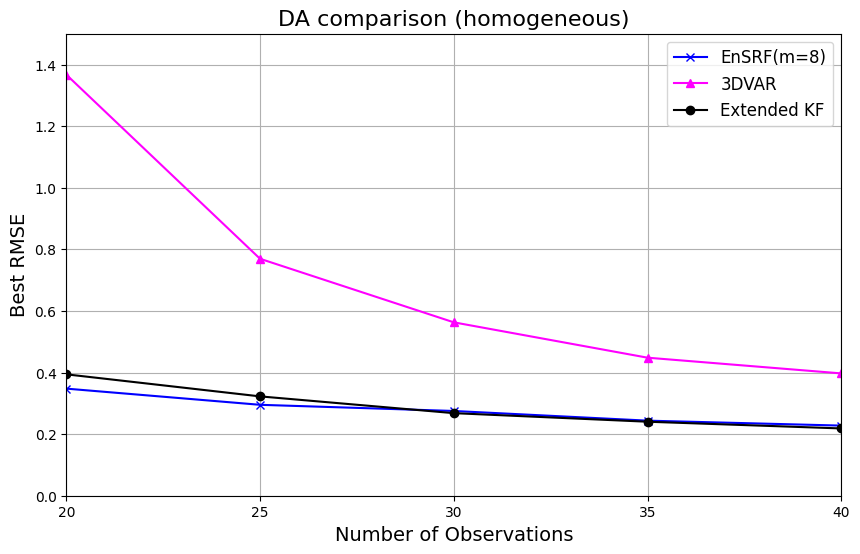

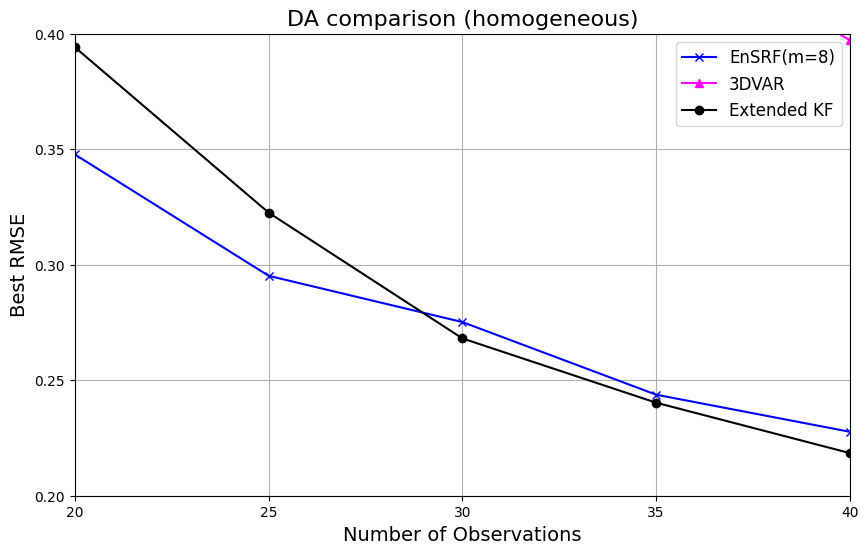

In [89]:
# member_size = 8でメンバー数を固定し、観測点数を変化させた場合のrmse_matrixを読み込み、観測点数ごとの最小のRMSE(Nanを除く)をプロットするコード
import numpy as np
member_size = 8  # メンバー数を固定
n_obs_list = [20, 25, 30, 35, 40]  # 観測変数の数のリスト
min_rmse_values_EnSRF = []
for n_obs in n_obs_list:
    with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}_p{n_obs}homogeneous.npy', 'rb') as f:
        rmse_matrix = np.load(f)
    # NaNを除いた最小値を計算
    min_rmse = np.nanmin(rmse_matrix)
    min_rmse_values_EnSRF.append(min_rmse)

# 横軸: 観測点数、縦軸: 最小RMSEのプロット
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(n_obs_list, min_rmse_values_EnSRF, marker='x', linestyle='-', color='blue', label=f'EnSRF(m={member_size})')
plt.plot(n_obs_list, min_rmse_values_3dvar, marker='^', linestyle='-', color='magenta', label='3DVAR')
plt.plot(n_obs_list, min_rmse_values_etf, marker='o', linestyle='-', color='black', label='Extended KF')
plt.title(f'DA comparison (homogeneous)', fontsize=16)
plt.xlabel('Number of Observations', fontsize=14)
plt.ylabel('Best RMSE', fontsize=14)
plt.xticks(n_obs_list)
plt.yticks(np.arange(0, 1.6, 0.2))
plt.xlim(min(n_obs_list), max(n_obs_list))
plt.ylim(0, 1.5)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# 同様のプロットを0.2から0.4までの範囲で拡大して表示するコード
plt.figure(figsize=(10, 6))
plt.plot(n_obs_list, min_rmse_values_EnSRF, marker='x', linestyle='-', color='blue', label=f'EnSRF(m={member_size})')
plt.plot(n_obs_list, min_rmse_values_3dvar, marker='^', linestyle='-', color='magenta', label='3DVAR')
plt.plot(n_obs_list, min_rmse_values_etf, marker='o', linestyle='-', color='black', label='Extended KF')
plt.title(f'DA comparison (homogeneous)', fontsize=16)
plt.xlabel('Number of Observations', fontsize=14)
plt.ylabel('Best RMSE', fontsize=14)
plt.xticks(n_obs_list)
plt.yticks(np.arange(0.2, 0.45, 0.05))
plt.xlim(min(n_obs_list), max(n_obs_list))
plt.ylim(0.2, 0.4)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [90]:
# ETFと3DVARの観測地点数を変化させた場合の10-300daysの平均RMSEを計算し、プロットするコード
# 観測データの読み込み
observed_states = np.load('observed_states.npy')
true_states = np.load('true_states.npy')  # 真値も読み込む

# パラメータ設定
N = 40
F = 8.0
dt = 0.05
step_day = 0.2 # 1日あたりのステップ幅
assim_interval = 0.05# データ同化間隔
steps_per_assim = int(assim_interval / dt)  # 同化間隔ごとのステップ数

# Store results for all inflation factors
results_dict = {}

p_values = [20, 25, 30, 35, 40]

for p in p_values:
    print(f"\n=== Number of Observations: {p} ===")
    H = make_dense_H(n=N, p=p)
    # ThreeDVarインスタンスの作成
    three_d_var = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=0.26, H=H, use_constant_P=True, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.0)
    # Extended Kalman Filterインスタンスの作成
    etf = ThreeDVar(N, F, dt, obs_error_std=1.0, forecast_error_std=1.0, H=H, use_constant_P=False, method='rk4', way='Numerical', delta=1e-5, inflation_factor=1.1)

    # 初期状態の設定
    spinup = StateArray(N, F, dt, method='rk4')
    np.random.seed(42)  # For reproducibility
    random_steps = np.random.randint(0, int(365 * 0.2 / dt))
    for _ in range(random_steps):
        spinup.step()
    three_d_var.initialize_state(spinup.x.copy())
    etf.initialize_state(spinup.x.copy())
    # データ同化の実行
    num_assim = len(observed_states)
    for k in range(num_assim):
        three_d_var.assimilate(observed_states[k], steps_per_assim, H)
        etf.assimilate(observed_states[k], steps_per_assim, H)
        if (k % 100) == 0:
            print(f"Assimilating cycle {k}/{num_assim}")
    # RMSEの計算
    rmse_analysis_3dvar, rmse_forecast_3dvar = three_d_var.compute_rmse(true_states)
    rmse_analysis_etf, rmse_forecast_etf = etf.compute_rmse(true_states)
    # 結果を保存
    results_dict[p] = {
        'rmse_analysis_3dvar': rmse_analysis_3dvar,
        'rmse_forecast_3dvar': rmse_forecast_3dvar,
        'rmse_analysis_etf': rmse_analysis_etf,
        'rmse_forecast_etf': rmse_forecast_etf
    }

# 保存したresults_dictを使って10-300daysの平均RMSEを計算し、それぞれmin_rmse_values_3dvarとmin_rmse_values_etfに格納
min_rmse_values_3dvar = []
min_rmse_values_etf = []
for p in p_values:
    data = results_dict[p]
    rmse_analysis_3dvar = data['rmse_analysis_3dvar']
    rmse_analysis_etf = data['rmse_analysis_etf']
    
    start_idx = int(10 * (step_day / dt) / steps_per_assim)
    end_idx = int(300 * (step_day / dt) / steps_per_assim) + 1
    avg_rmse_3dvar = np.mean(rmse_analysis_3dvar[start_idx:end_idx])
    avg_rmse_etf = np.mean(rmse_analysis_etf[start_idx:end_idx])
    min_rmse_values_3dvar.append(avg_rmse_3dvar)
    min_rmse_values_etf.append(avg_rmse_etf)


=== Number of Observations: 20 ===
Assimilating cycle 0/1460


C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_17020\1757141609.py:16: RuntimeWarning: overflow encountered in multiply
  return (roll_p1 - roll_m2) * roll_m1 - x + F
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_17020\4194845163.py:114: RuntimeWarning: invalid value encountered in subtract
  M[:, i] = (f_plus - f) / delta
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_17020\4194845163.py:166: RuntimeWarning: overflow encountered in matmul
  self.P_forecast = M @ self.P_analysis @ M.T * self.inflation_factor  # インフレーションを適用
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_17020\4194845163.py:166: RuntimeWarning: invalid value encountered in matmul
  self.P_forecast = M @ self.P_analysis @ M.T * self.inflation_factor  # インフレーションを適用
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_17020\4194845163.py:193: RuntimeWarning: invalid value encountered in matmul
  innovation = H @ observation - H @ self.x_forecast


Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460


C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_17020\4194845163.py:253: RuntimeWarning: overflow encountered in square
  rmse_forecast = np.sqrt(np.mean((forecast_array - true_states)**2, axis=1))



=== Number of Observations: 25 ===
Assimilating cycle 0/1460


C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_17020\1757141609.py:16: RuntimeWarning: invalid value encountered in subtract
  return (roll_p1 - roll_m2) * roll_m1 - x + F
C:\Users\miyazawa_kento\AppData\Local\Temp\ipykernel_17020\1757141609.py:39: RuntimeWarning: invalid value encountered in add
  return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6


Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460

=== Number of Observations: 30 ===
Assimilating cycle 0/1460
Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/1460
Assimilating cycle 400/1460
Assimilating cycle 500/1460
Assimilating cycle 600/1460
Assimilating cycle 700/1460
Assimilating cycle 800/1460
Assimilating cycle 900/1460
Assimilating cycle 1000/1460
Assimilating cycle 1100/1460
Assimilating cycle 1200/1460
Assimilating cycle 1300/1460
Assimilating cycle 1400/1460

=== Number of Observations: 35 ===
Assimilating cycle 0/1460
Assimilating cycle 100/1460
Assimilating cycle 200/1460
Assimilating cycle 300/146

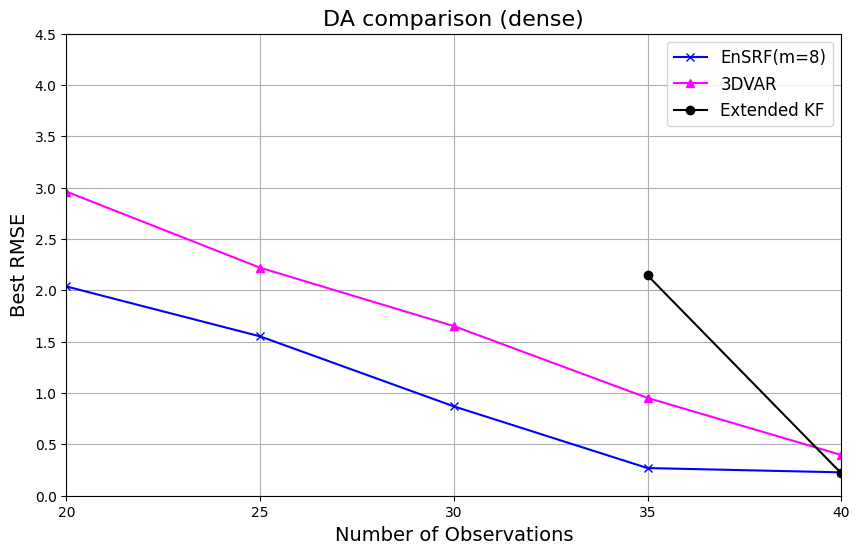

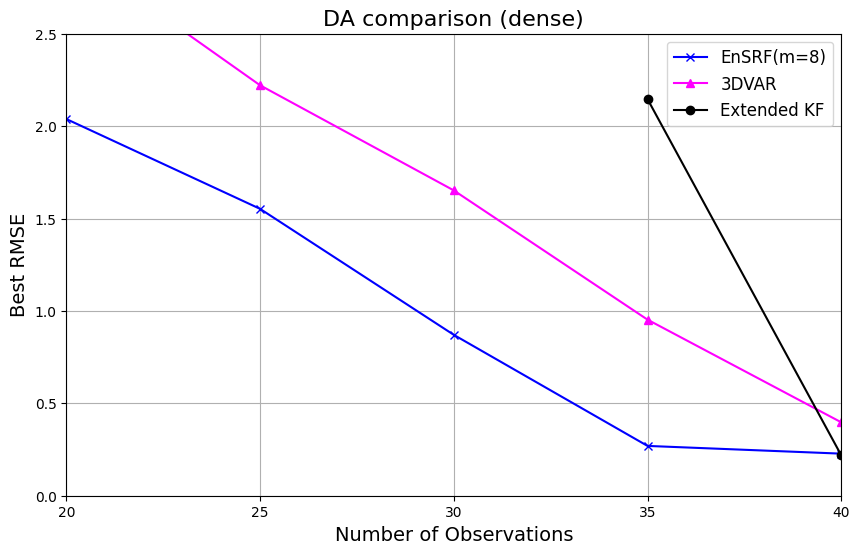

In [91]:
# member_size = 8でメンバー数を固定し、観測点数を変化させた場合のrmse_matrixを読み込み、観測点数ごとの最小のRMSE(Nanを除く)をプロットするコード
import numpy as np
member_size = 8  # メンバー数を固定
n_obs_list = [20, 25, 30, 35, 40]  # 観測変数の数のリスト
min_rmse_values_EnSRF = []
for n_obs in n_obs_list:
    with open(f'enkf_serial_ensrf_rmse_matrix_m{member_size}_p{n_obs}dense.npy', 'rb') as f:
        rmse_matrix = np.load(f)
    # NaNを除いた最小値を計算
    min_rmse = np.nanmin(rmse_matrix)
    min_rmse_values_EnSRF.append(min_rmse)

# 横軸: 観測点数、縦軸: 最小RMSEのプロット
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(n_obs_list, min_rmse_values_EnSRF, marker='x', linestyle='-', color='blue', label=f'EnSRF(m={member_size})')
plt.plot(n_obs_list, min_rmse_values_3dvar, marker='^', linestyle='-', color='magenta', label='3DVAR')
plt.plot(n_obs_list, min_rmse_values_etf, marker='o', linestyle='-', color='black', label='Extended KF')
plt.title(f'DA comparison (dense)', fontsize=16)
plt.xlabel('Number of Observations', fontsize=14)
plt.ylabel('Best RMSE', fontsize=14)
plt.xticks(n_obs_list)
plt.yticks(np.arange(0, 5, 0.5))
plt.xlim(min(n_obs_list), max(n_obs_list))
plt.ylim(0, 4.5)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# 同様のプロットを0.2から0.4までの範囲で拡大して表示するコード
plt.figure(figsize=(10, 6))
plt.plot(n_obs_list, min_rmse_values_EnSRF, marker='x', linestyle='-', color='blue', label=f'EnSRF(m={member_size})')
plt.plot(n_obs_list, min_rmse_values_3dvar, marker='^', linestyle='-', color='magenta', label='3DVAR')
plt.plot(n_obs_list, min_rmse_values_etf, marker='o', linestyle='-', color='black', label='Extended KF')
plt.title(f'DA comparison (dense)', fontsize=16)
plt.xlabel('Number of Observations', fontsize=14)
plt.ylabel('Best RMSE', fontsize=14)
plt.xticks(n_obs_list)
plt.yticks(np.arange(0, 2.6, 0.5))
plt.xlim(min(n_obs_list), max(n_obs_list))
plt.ylim(0, 2.5)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()